<a href="https://colab.research.google.com/github/Lokeshvuyyuru/Lokeshvuyyuru/blob/main/Data_driven_real_estate_validation_Advanced_Predictive_modeling_techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import sklearn
import xgboost
print("Scikit-learn version:", sklearn.__version__)
print("XGBoost version:", xgboost.__version__)

Scikit-learn version: 1.6.1
XGBoost version: 2.1.4


In [ ]:

from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.5 MB/s eta 0:00:00


In [ ]:
!pip install xgboost

In [ ]:
!pip install lightgbm

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from xgboost import XGBRegressor

import lightgbm as lgb

In [ ]:
train_df= pd.read_csv('/content/train.csv')
test_df= pd.read_csv('/content/test.csv')

In [ ]:
train_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [ ]:
def plot_data_scatterplot_for_train_df(x):

   plt.figure(figsize=(5, 3))
   sns.scatterplot(x=x, y='SalePrice', data=train_df)
   plt.title('Scatter plot')
   plt.show()

In [ ]:
pd.DataFrame(train_df.isnull().sum().sort_values(ascending=False)).head(20)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageYrBlt,81
GarageCond,81
GarageType,81


<Axes: >

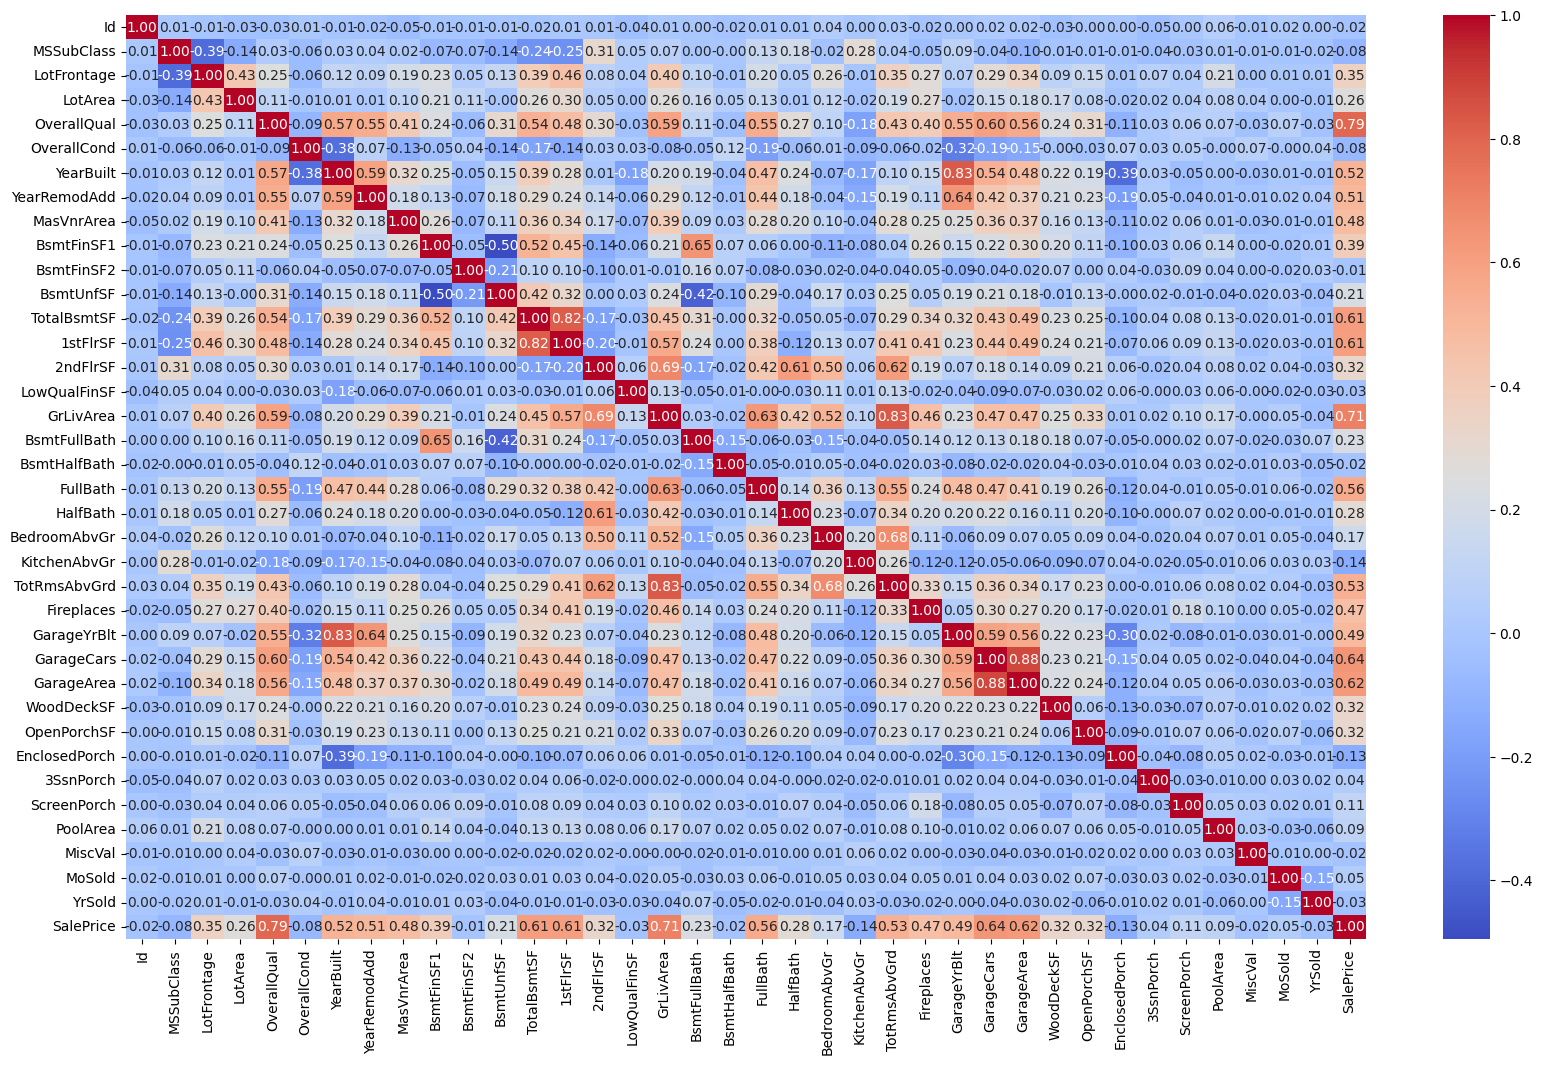

In [ ]:
correlation_matrix = train_df.corr(numeric_only=True)


plt.figure(figsize=(20,12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

<Axes: xlabel='SalePrice', ylabel='Count'>

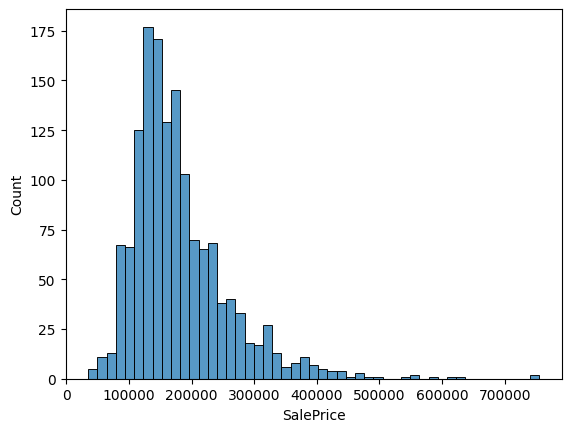

In [ ]:
sns.histplot(
    train_df,
    x=train_df['SalePrice']
)

In [ ]:
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('SalePrice')

In [ ]:
num_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
ode_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
ohe_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [ ]:
X = train_df.drop('SalePrice', axis=1)
y = train_df['SalePrice']

In [ ]:
ode_cols = ['LotShape', 'LandContour','Utilities','LandSlope',  'BsmtQual',  'BsmtFinType1',  'CentralAir',  'Functional', 'PoolQC','Fence',

           'FireplaceQu', 'GarageFinish', 'GarageQual', 'PavedDrive', 'ExterCond', 'KitchenQual', 'BsmtExposure', 'HeatingQC','ExterQual', 'BsmtCond']
ohe_cols = ['Street', 'LotConfig','Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd',
           'MasVnrType','Foundation',  'Electrical',  'SaleType', 'MSZoning', 'SaleCondition', 'Heating', 'GarageType', 'RoofMatl','MiscFeature','Alley']

In [ ]:
col_trans = ColumnTransformer(transformers=[
    ('num_p', num_pipeline, num_cols),
    ('ode_p', ode_pipeline, ode_cols),
    ('ohe_p', ohe_pipeline, ohe_cols),
    ],
    remainder='passthrough',
    n_jobs=-1)

In [ ]:
X_preprocessed = col_trans.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=25)

In [ ]:
import sklearn
import xgboost
print("Scikit-learn version:", sklearn.__version__)
print("XGBoost version:", xgboost.__version__)


Scikit-learn version: 1.6.1
XGBoost version: 2.1.4


In [ ]:
#!pip install scikit-learn==1.2.2

In [ ]:
# Assuming 'Unf' comes from a column named 'BsmtFinType1' or similar:
# Find columns with object dtype, indicating they may contain strings
# Corrected to handle both str and np.str_ and consider all columns
#object_cols = [col for col in range(X_train.shape[1]) if isinstance(X_train[0, col], (str, np.str_))]
#object_cols_test = [col for col in range(X_test.shape[1]) if isinstance(X_test[0, col], (str, np.str_))]

# Instead of manually searching for 'Unf', use OrdinalEncoder to encode all strings
from sklearn.preprocessing import OrdinalEncoder

# Create an instance of OrdinalEncoder
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Combine X_train and X_test to ensure all categories are seen during fitting
X_combined = np.concatenate([X_train, X_test], axis=0)

# Instead of checking individual cells, check the data type of each column
object_cols_combined = [col for col in range(X_combined.shape[1]) if X_combined[:, col].dtype == 'O']

# Fit and transform the encoder on the object columns of the combined data
if object_cols_combined:
    X_combined[:, object_cols_combined] = encoder.fit_transform(X_combined[:, object_cols_combined].astype(str))

# Split the data back into train and test sets
X_train = X_combined[:X_train.shape[0], :]
X_test = X_combined[X_train.shape[0]:, :]

# Convert all columns in X_train to numeric
X_train = X_train.astype(float)

# Repeat the same for X_test
X_test = X_test.astype(float)

In [ ]:
#np.sqrt(-1 * xgb_cv.best_score_)

In [ ]:
XGB = XGBRegressor(random_state=13)
param_grid_XGB = {
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [300],
    'max_depth': [3],
    'min_child_weight': [1,2,3],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],}
xgb_cv = GridSearchCV(XGB, param_grid_XGB, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
xgb_cv.fit(X_train, y_train)
xgb_cv.best_params_

{'colsample_bytree': 0.8,
 'gamma': 0,
 'learning_rate': 0.05,
 'max_depth': 3,
 'min_child_weight': 2,
 'n_estimators': 300,
 'subsample': 0.8}

In [ ]:
xgb_final = XGBRegressor(random_state=13,colsample_bytree= 0.8,gamma= 0,learning_rate= 0.05,max_depth= 3,min_child_weight= 3,n_estimators=300,subsample= 0.8)
xgb_final.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=3, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=13, ...)

In [ ]:
np.sqrt(-1 * xgb_cv.best_score_)

30905.62701731407

In [ ]:
ridge = Ridge()

param_grid_ridge = {
    'alpha': [0.05, 0.1, 1, 3, 5, 10],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag']
}
ridge_cv = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
ridge_cv.fit(X_train, y_train)
print(np.sqrt(-1 * ridge_cv.best_score_))
ridge_cv.best_params_

31521.823554336846


{'alpha': 3, 'solver': 'svd'}

In [ ]:
import sklearn
import xgboost
print("Scikit-learn version:", sklearn.__version__)
print("XGBoost version:", xgboost.__version__)

# Install/reinstall joblib
!pip install --upgrade joblib

# Restart kernel here (Manually interrupt and restart in Jupyter)

# ... (rest of your code) ...

ridge = Ridge()

param_grid_ridge = {
    'alpha': [0.05, 0.1, 1, 3, 5, 10],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag']
}
ridge_cv = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
ridge_cv.fit(X_train, y_train)
print(np.sqrt(-1 * ridge_cv.best_score_))
ridge_cv.best_params_


Scikit-learn version: 1.6.1
XGBoost version: 2.1.4
31521.823554336846


{'alpha': 3, 'solver': 'svd'}

In [ ]:
np.sqrt(-1 * ridge_cv.best_score_)

31521.823554336846

In [ ]:
ridge_final=Ridge(alpha=10, solver= 'sag')
ridge_final.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Ridge(alpha=10, solver='sag')

In [ ]:
lgbm_regressor = lgb.LGBMRegressor()
param_grid_lgbm = {
    'boosting_type': ['gbdt', 'dart'],
    'num_leaves': [20, 30, 40],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'verbosity': [-1]
}
lgbm_cv = GridSearchCV(lgbm_regressor, param_grid_lgbm, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
lgbm_cv.fit(X_train, y_train)
lgbm_cv.best_params_

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


{'boosting_type': 'gbdt',
 'learning_rate': 0.05,
 'n_estimators': 100,
 'num_leaves': 40,
 'verbosity': -1}

In [ ]:
np.sqrt(-1 * lgbm_cv.best_score_)

29767.65327994439

In [ ]:
lgbm_final = lgb.LGBMRegressor(boosting_type= 'gbdt',learning_rate= 0.05,n_estimators= 200,num_leaves=20)
lgbm_final.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001184 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3523
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 133
[LightGBM] [Info] Start training from score 179237.415240


LGBMRegressor(learning_rate=0.05, n_estimators=200, num_leaves=20)

In [ ]:
catboost = CatBoostRegressor(loss_function='RMSE', verbose=False)
param_grid_cat ={
    'iterations': [100, 500, 1000],
    'depth': [5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.5]
}
cat_cv = GridSearchCV(catboost, param_grid_cat, cv=2, scoring='neg_mean_squared_error', n_jobs=-1)
cat_cv.fit(X_train, y_train)
cat_cv.best_params_

{'depth': 5, 'iterations': 1000, 'learning_rate': 0.05}

In [ ]:
catboost_final=CatBoostRegressor(loss_function='RMSE', verbose=False,depth=5,iterations= 500, learning_rate= 0.05)
catboost_final.fit(X_train, y_train)

In [ ]:
gbr = GradientBoostingRegressor(random_state=13)
param_grid_gbr = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
gbr_cv = GridSearchCV(gbr, param_grid_gbr, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
gbr_cv.fit(X_train, y_train)
gbr_final = gbr_cv.best_estimator_
gbr_cv.best_params_
cat_cv.best_params_


{'depth': 5, 'iterations': 1000, 'learning_rate': 0.05}

In [ ]:
np.sqrt(-1*gbr_cv.best_score_)

32207.366010588157

In [ ]:
cat_cv.predict_proba(X_test)

AttributeError: This 'GridSearchCV' has no attribute 'predict_proba'

In [ ]:
# Get prediction probabilities from the best estimator found by GridSearchCV
y_pred_proba = cat_cv.best_estimator_.predict(X_test)

print(y_pred_proba)

[293956.32856933 304513.10319864 169471.64264474 261264.91649662
 166538.43418075 200392.04578578 216314.35396102 235637.82795954
 176525.91799431 176922.6901029  374273.26243587 158696.15242149
 343730.96240406 234627.9298272  334192.47685575 163162.93128299
 179460.56156013 124672.45232041 159930.58209033 228217.71147064
 134528.64499173 431220.99280642 219587.08059499 168600.72051815
 134871.92421207  96500.25215524 154399.15514187 332254.7861449
 290256.40549833 115324.04942756 231255.0346113  195562.49114406
 137370.20764773 348708.5347849  160790.84526372 255494.25122028
 275502.55006996 166540.4968882   97551.29093446 139736.23963814
 195093.56645559 187850.69242278 184302.89417303 135763.48566441
 184211.3776555  186140.22036553 144185.98973352 194353.51829057
  99811.22585337 243237.513825   163356.7108381  115871.93455972
 108916.07578277 208993.9248653  209313.07840411 107743.85412019
 191659.35546087 121894.7745003  191882.71019336 238936.94173635
 108717.81637333 181178.78

In [ ]:
np.sqrt(-1 * cat_cv.best_score_)

28499.39691061753

In [ ]:
# Get prediction probabilities
y_pred_proba = cat_cv.predict(X_test)  # Assuming the positive class is the second column

print(y_pred_proba)
# Plot the ROC curve
fpr, tpr, auc_score = plot_roc_curve(y_test, y_pred_proba, "Logistic Regression")
plt.show()

[293956.32856933 304513.10319864 169471.64264474 261264.91649662
 166538.43418075 200392.04578578 216314.35396102 235637.82795954
 176525.91799431 176922.6901029  374273.26243587 158696.15242149
 343730.96240406 234627.9298272  334192.47685575 163162.93128299
 179460.56156013 124672.45232041 159930.58209033 228217.71147064
 134528.64499173 431220.99280642 219587.08059499 168600.72051815
 134871.92421207  96500.25215524 154399.15514187 332254.7861449
 290256.40549833 115324.04942756 231255.0346113  195562.49114406
 137370.20764773 348708.5347849  160790.84526372 255494.25122028
 275502.55006996 166540.4968882   97551.29093446 139736.23963814
 195093.56645559 187850.69242278 184302.89417303 135763.48566441
 184211.3776555  186140.22036553 144185.98973352 194353.51829057
  99811.22585337 243237.513825   163356.7108381  115871.93455972
 108916.07578277 208993.9248653  209313.07840411 107743.85412019
 191659.35546087 121894.7745003  191882.71019336 238936.94173635
 108717.81637333 181178.78

NameError: name 'plot_roc_curve' is not defined

In [ ]:
vr = VotingRegressor([
                      ('xgb', xgb_final),
                      ('ridge', ridge_final),
                      ('lgbm',lgbm_final),
                      ('cat',catboost_final)],
                    weights=[2,1,1,1])
vr.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


VotingRegressor(estimators=[('xgb',
                             XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=0.8, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=0, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=0.0...
                                          max_leaves=None, min_child_weight=3,
                                          missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None, n_estimators=300,
                                          n_jobs=None, num_parallel_tree=None,
                                          random_state=13, ...)),
                            ('ridge', Ridge(alpha=10, solver='sag')),
                            ('lgbm',
                             LGBMRegressor(learning_rate=0.05, n_estimators=200,
                                           num_leaves=20)),
                            ('cat',
                             <catboost.core.CatBoostRegressor object at 0x7b77117574d0>)],
                weights=[2, 1, 1, 1])

In [ ]:
y_pred_vr = vr.predict(X_test)
# Calculate MSE and then take the square root for RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_vr))
print(rmse) # or whatever you want to do with the RMSE value

30447.091825134048


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
estimators = [

    ('xgb', xgb_final),
    ('cat', catboost_final),
    ('lgb', lgbm_final),
    ('ridge', ridge_final)

]
stackreg = StackingRegressor(
            estimators = estimators,
    final_estimator= vr

)
stackreg.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklea

StackingRegressor(estimators=[('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=0,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0...
                                                                            max_leaves=None,
                                                                            min_child_weight=3,
                                                                            missing=nan,
                                                                            monotone_constraints=None,
                                                                            multi_strategy=None,
                                                                            n_estimators=300,
                                                                            n_jobs=None,
                                                                            num_parallel_tree=None,
                                                                            random_state=13, ...)),
                                                              ('ridge',
                                                               Ridge(alpha=10,
                                                                     solver='sag')),
                                                              ('lgbm',
                                                               LGBMRegressor(learning_rate=0.05,
                                                                             n_estimators=200,
                                                                             num_leaves=20)),
                                                              ('cat',
                                                               <catboost.core.CatBoostRegressor object at 0x7b77117574d0>)],
                                                  weights=[2, 1, 1, 1]))

In [ ]:
# prompt: can you give roc curve for the xgboot model

# Assuming 'y_test' is your true labels and you have a trained model (e.g., xgb_final)
y_pred_proba = xgb_final.predict(X_test)

# Since XGBoost is a regression model, you need to define a threshold to convert predictions
# into binary classes for ROC curve calculation.
threshold = y_train.median()  # Example: Use the median of the training target as a threshold
y_pred_binary = (y_pred_proba > threshold).astype(int)

# Now you can calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba) #use y_pred_proba here
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()


NameError: name 'roc_curve' is not defined

In [ ]:
from sklearn.metrics import mean_squared_error

# Your existing code ...

# Fit the stacking regressor
stackreg.fit(X_train, y_train)

# Make predictions
y_pred_stack = stackreg.predict(X_test)

# Calculate RMSE
rmse_stack = mean_squared_error(y_test, y_pred_stack, squared=False)

# Print RMSE
print(f"RMSE of the stacking regressor: {rmse_stack}")

# Check lengths
print(f"Length of y_test: {len(y_test)}")
print(f"Length of y_pred_stack: {len(y_pred_stack)}")

# Additional evaluation (if needed)
# You might also want to consider plotting the predicted vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_stack, alpha=0.5)
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted Sale Price (Stacking Regressor)')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2)  # Diagonal line
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklea

TypeError: got an unexpected keyword argument 'squared'

In [ ]:
from sklearn.metrics import mean_squared_error

# ... (Your existing code) ...

# Calculate RMSE
# If using scikit-learn version 0.22 or later:
# rmse_stack = mean_squared_error(y_test, y_pred_stack, squared=False)

# For older versions or if 'squared' is not available:
mse_stack = mean_squared_error(y_test, y_pred_stack)  # Calculate MSE
rmse_stack = np.sqrt(mse_stack)  # Calculate RMSE manually

# Print RMSE
print(f"RMSE of the stacking regressor: {rmse_stack}")

# ... (Rest of your code) ...

RMSE of the stacking regressor: 32302.108342389572


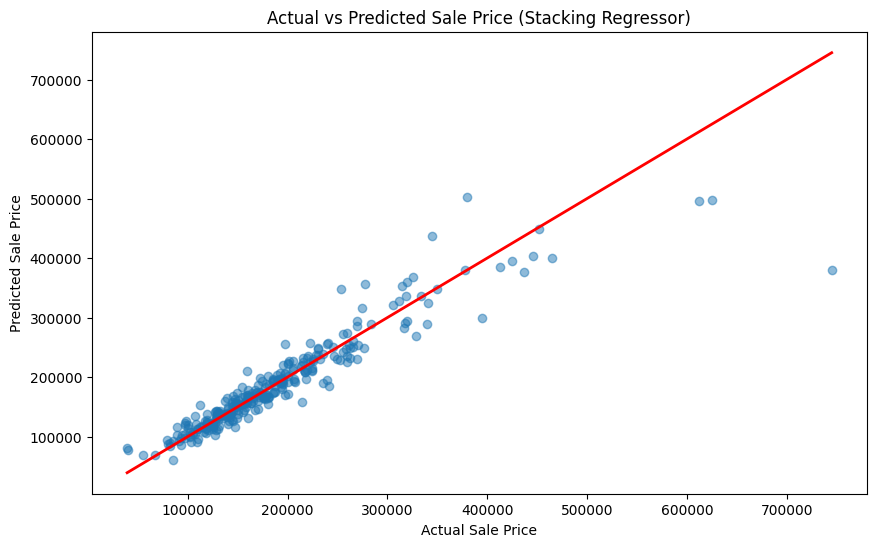

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_stack, alpha=0.5)
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted Sale Price (Stacking Regressor)')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2)  # Diagonal line
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Define a function to evaluate and print model performance on test data
def evaluate_models(models, X_test, y_test):
    results = []
    for model_name, model in models.items():
        # Predict on test data
        y_pred = model.predict(X_test)

        # Calculate evaluation metrics
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        # Append results
        results.append([model_name, mae, rmse, r2])

    # Convert to DataFrame for better readability
    results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score"])
    results_df.sort_values(by="RMSE", inplace=True)  # Sorting by RMSE for easy comparison

    # Display results
    display(results_df)

# Create a dictionary with your models
models = {

    "XGBoost": xgb_final,
    "Ridge Regression": ridge_final,
    "LightGBM": lgbm_final,
    "CatBoost": catboost_final
}

# Call the evaluation function
evaluate_models(models, X_test, y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Model,MAE,RMSE,R2 Score
3,CatBoost,15851.088842,28582.640496,0.894592
0,XGBoost,17044.876953,30102.200318,0.883087
2,LightGBM,17785.847485,31522.440799,0.871794
1,Ridge Regression,24890.218291,40834.177989,0.784863


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Model,MAE,RMSE,R2 Score
3,CatBoost,15851.088842,28582.640496,0.894592
0,XGBoost,17044.876953,30102.200318,0.883087
2,LightGBM,17785.847485,31522.440799,0.871794
1,Ridge Regression,24890.218291,40834.177989,0.784863


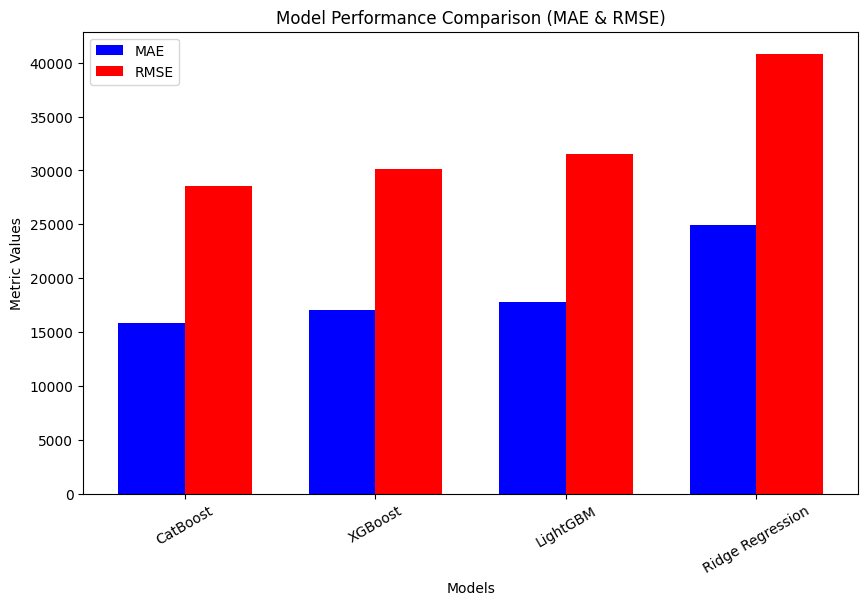

In [ ]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define a function to evaluate and plot model performance on test data
def evaluate_models(models, X_test, y_test):
    results = []

    for model_name, model in models.items():
        # Predict on test data
        y_pred = model.predict(X_test)

        # Calculate evaluation metrics
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        # Append results
        results.append([model_name, mae, rmse, r2])

    # Convert to DataFrame
    results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score"])
    results_df.sort_values(by="RMSE", inplace=True)  # Sorting by RMSE for better visualization

    # Display results
    display(results_df)

    # Extracting values for plotting
    models_list = results_df["Model"]
    mae_values = results_df["MAE"]
    rmse_values = results_df["RMSE"]

    # Plotting MAE and RMSE
    x = np.arange(len(models_list))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.bar(x - width/2, mae_values, width, label="MAE", color="blue")
    ax.bar(x + width/2, rmse_values, width, label="RMSE", color="red")

    ax.set_xlabel("Models")
    ax.set_ylabel("Metric Values")
    ax.set_title("Model Performance Comparison (MAE & RMSE)")
    ax.set_xticks(x)
    ax.set_xticklabels(models_list, rotation=30)
    ax.legend()

    plt.show()

# Create a dictionary with your models
models = {
    "XGBoost": xgb_final,
    "Ridge Regression": ridge_final,
    "LightGBM": lgbm_final,
    "CatBoost": catboost_final
}

# Call the evaluation function
evaluate_models(models, X_test, y_test)


Fold 1
RMSE for Fold 1: 19907.928068987992


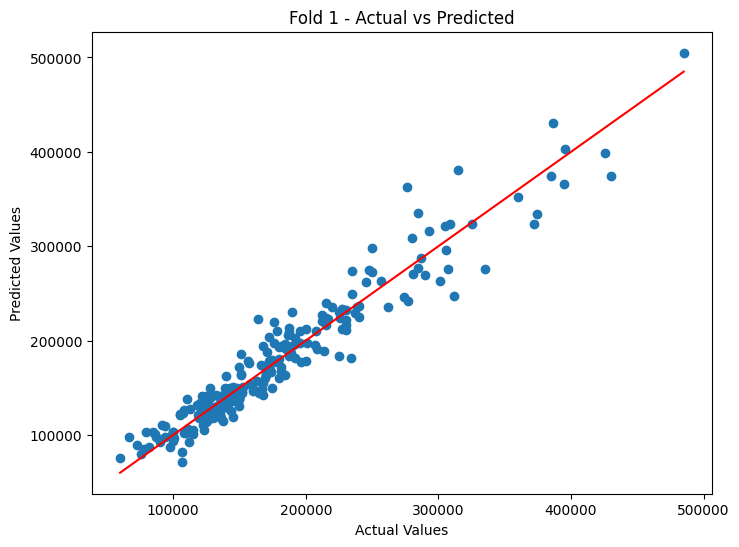

Fold 2
RMSE for Fold 2: 25798.0203891694


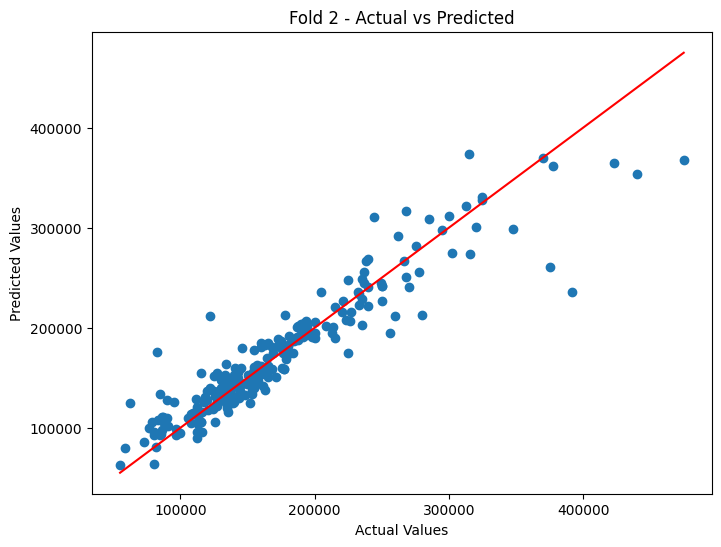

Fold 3
RMSE for Fold 3: 41855.98929663472


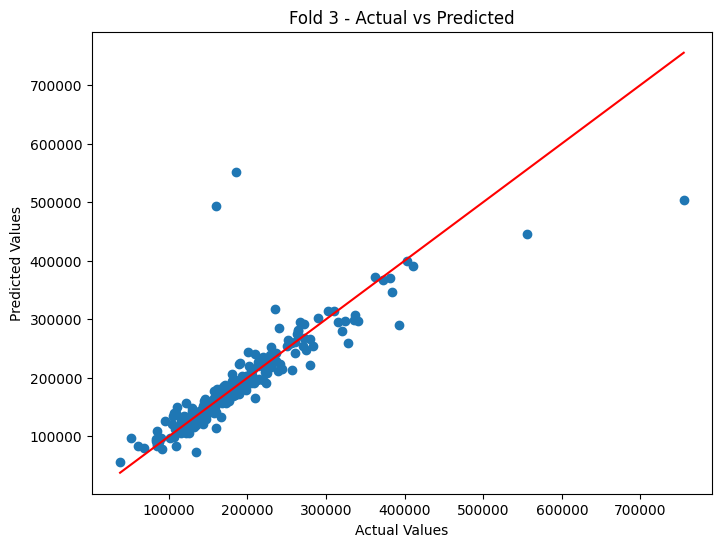

Fold 4
RMSE for Fold 4: 23330.835218654305


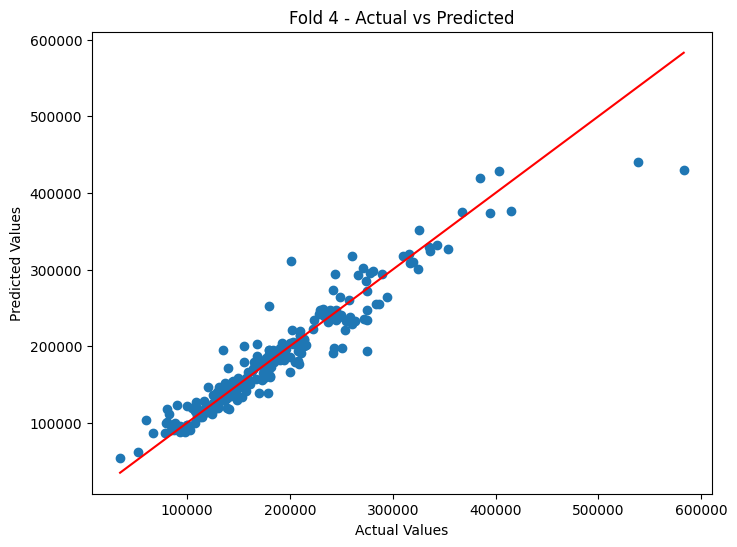

Fold 5
RMSE for Fold 5: 23080.966357585636


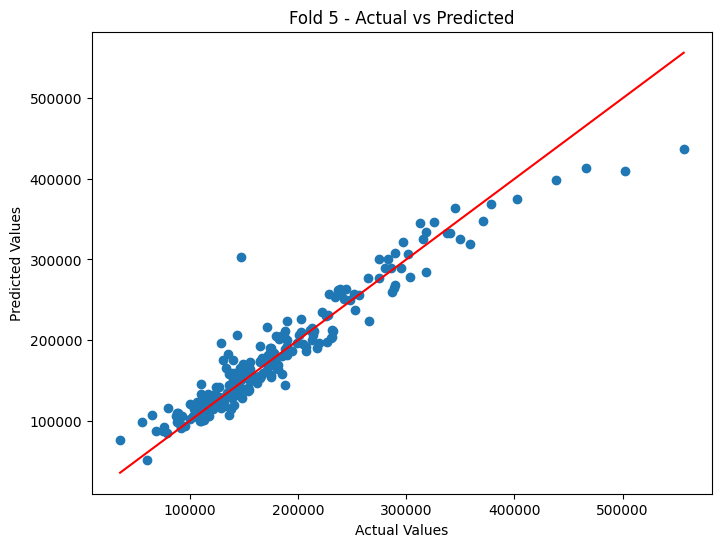

In [ ]:
# prompt: k fold cross validation with k=5 and give different graphs for 5 folds

from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

# ... (Your existing code) ...

# Define the number of folds for k-fold cross-validation
n_splits = 5

# Initialize KFold
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)  # Set random_state for reproducibility

# Iterate through the folds
fold_idx = 1
for train_index, test_index in kf.split(X_train):
    print(f"Fold {fold_idx}")

    # Split the data into training and validation sets for the current fold
    X_train_fold, X_val_fold = X_train[train_index], X_train[test_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[test_index]


    # Fit your model on the training data for this fold
    # Example using XGBRegressor (replace with your desired model)

    xgb_final.fit(X_train_fold, y_train_fold)

    # Make predictions on the validation set
    y_pred_fold = xgb_final.predict(X_val_fold)

    # Calculate evaluation metrics (e.g., RMSE) for this fold
    rmse_fold = np.sqrt(mean_squared_error(y_val_fold, y_pred_fold))
    print(f"RMSE for Fold {fold_idx}: {rmse_fold}")

    #Plot for current fold
    plt.figure(figsize=(8, 6))
    plt.scatter(y_val_fold, y_pred_fold)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Fold {fold_idx} - Actual vs Predicted')
    plt.plot([min(y_val_fold), max(y_val_fold)], [min(y_val_fold), max(y_val_fold)], color='red')
    plt.show()

    fold_idx += 1


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

# Define the number of folds for k-fold cross-validation
n_splits = 5

# Initialize KFold
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)  # Set random_state for reproducibility

rmse_scores = []  # List to store RMSE for each fold

# Iterate through the folds
fold_idx = 1
for train_index, test_index in kf.split(X_train):
    print(f"Fold {fold_idx}")

    # Split the data into training and validation sets for the current fold
    X_train_fold, X_val_fold = X_train[train_index], X_train[test_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[test_index]

    # Fit your model on the training data for this fold
    xgb_final.fit(X_train_fold, y_train_fold)

    # Make predictions on the validation set
    y_pred_fold = xgb_final.predict(X_val_fold)

    # Calculate evaluation metrics (e.g., RMSE) for this fold
    rmse_fold = np.sqrt(mean_squared_error(y_val_fold, y_pred_fold))
    rmse_scores.append(rmse_fold)
    print(f"RMSE for Fold {fold_idx}: {rmse_fold}")

    fold_idx += 1

# Compute and print the average RMSE
average_rmse = np.mean(rmse_scores)
print(f"\nAverage RMSE across {n_splits} folds: {average_rmse:.4f}")


Fold 1
RMSE for Fold 1: 19907.928068987992
Fold 2
RMSE for Fold 2: 25798.0203891694
Fold 3
RMSE for Fold 3: 41855.98929663472
Fold 4
RMSE for Fold 4: 23330.835218654305
Fold 5
RMSE for Fold 5: 23080.966357585636

Average RMSE across 5 folds: 26794.7479


Fold 1
RMSE for Fold 1: 19907.928068987992


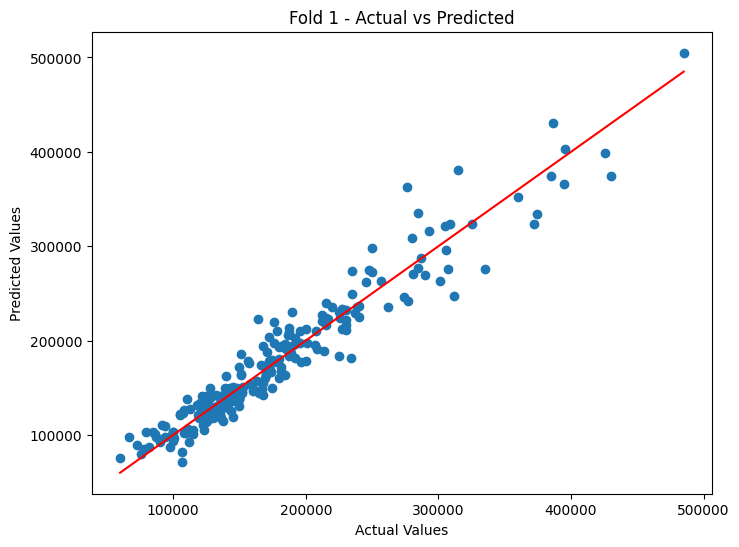

Fold 2
RMSE for Fold 2: 25798.0203891694


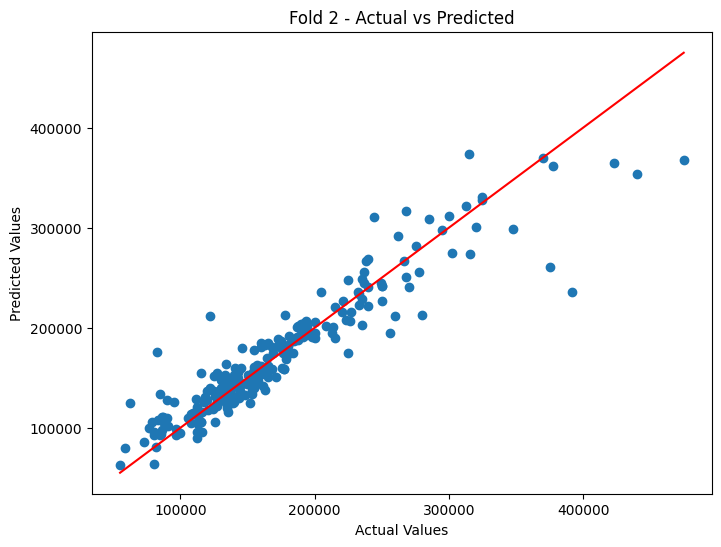

Fold 3
RMSE for Fold 3: 41855.98929663472


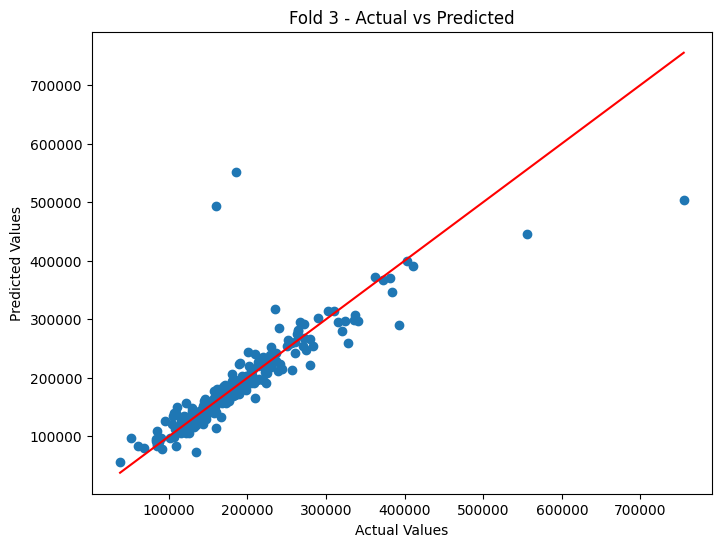

Fold 4
RMSE for Fold 4: 23330.835218654305


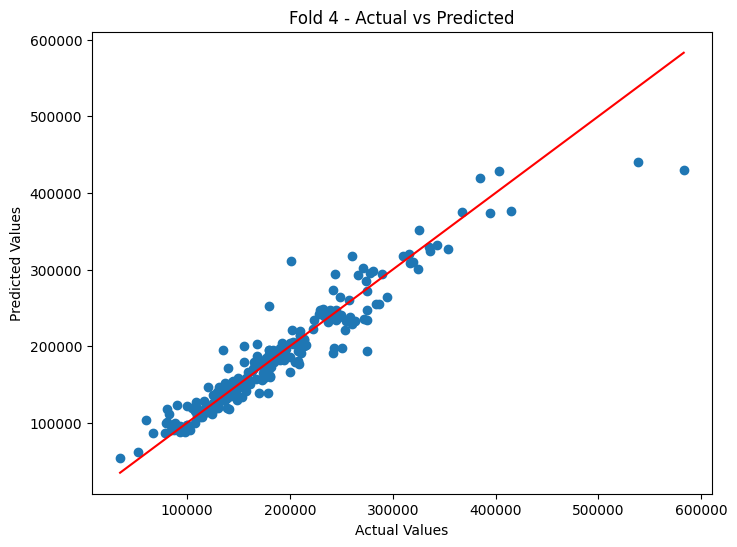

Fold 5
RMSE for Fold 5: 23080.966357585636


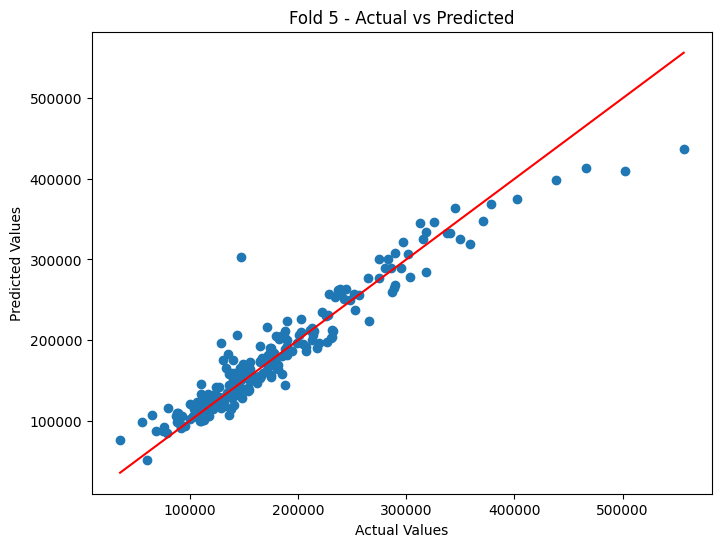

Average RMSE across 5 folds: 26794.747866206406


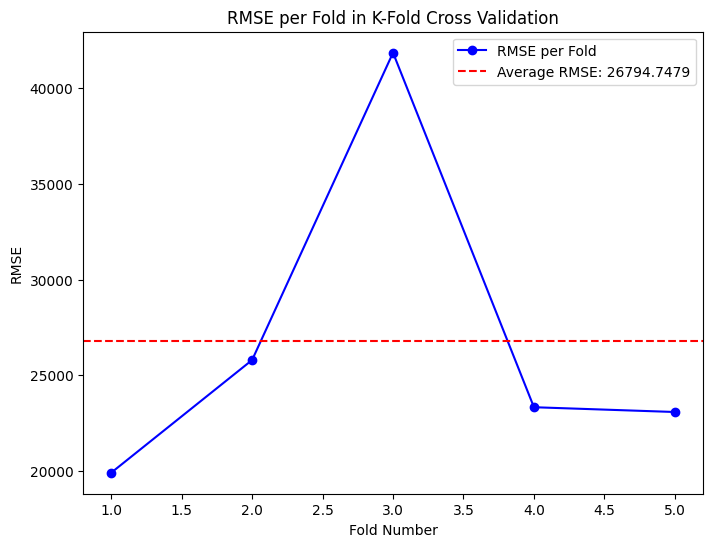

In [ ]:
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# Define the number of folds for k-fold cross-validation
n_splits = 5

# Initialize KFold
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)  # Set random_state for reproducibility

# List to store RMSE values for each fold
rmse_scores = []

# Iterate through the folds
fold_idx = 1
for train_index, test_index in kf.split(X_train):
    print(f"Fold {fold_idx}")

    # Split the data into training and validation sets for the current fold
    X_train_fold, X_val_fold = X_train[train_index], X_train[test_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[test_index]

    # Fit your model on the training data for this fold
    xgb_final.fit(X_train_fold, y_train_fold)

    # Make predictions on the validation set
    y_pred_fold = xgb_final.predict(X_val_fold)

    # Calculate evaluation metrics (e.g., RMSE) for this fold
    rmse_fold = np.sqrt(mean_squared_error(y_val_fold, y_pred_fold))
    rmse_scores.append(rmse_fold)
    print(f"RMSE for Fold {fold_idx}: {rmse_fold}")

    # Plot for current fold
    plt.figure(figsize=(8, 6))
    plt.scatter(y_val_fold, y_pred_fold)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Fold {fold_idx} - Actual vs Predicted')
    plt.plot([min(y_val_fold), max(y_val_fold)], [min(y_val_fold), max(y_val_fold)], color='red')
    plt.show()

    fold_idx += 1

# Calculate the average RMSE across all folds
average_rmse = np.mean(rmse_scores)
print(f"Average RMSE across {n_splits} folds: {average_rmse}")

# Plot RMSE values for each fold
plt.figure(figsize=(8, 6))
plt.plot(range(1, n_splits + 1), rmse_scores, marker='o', linestyle='-', color='blue', label='RMSE per Fold')
plt.axhline(y=average_rmse, color='red', linestyle='--', label=f'Average RMSE: {average_rmse:.4f}')
plt.xlabel('Fold Number')
plt.ylabel('RMSE')
plt.title('RMSE per Fold in K-Fold Cross Validation')
plt.legend()
plt.show()


K fold cross validation for **catboost**

Fold 1
RMSE for Fold 1: 21050.442272149096


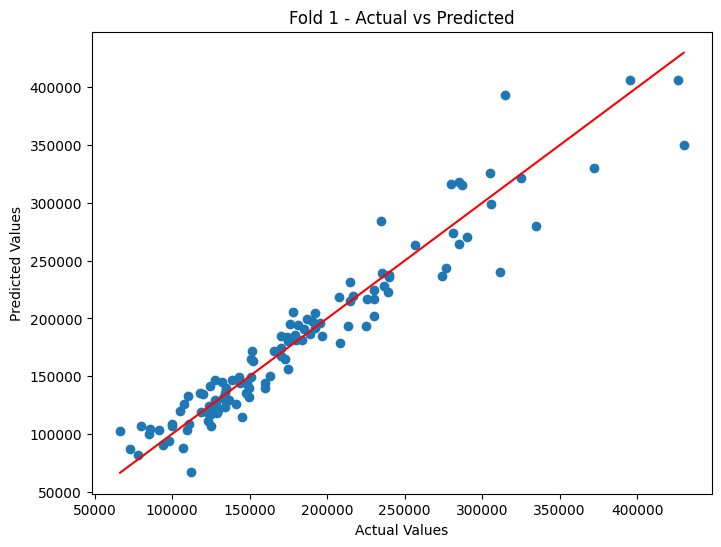

Fold 2
RMSE for Fold 2: 18403.901628551877


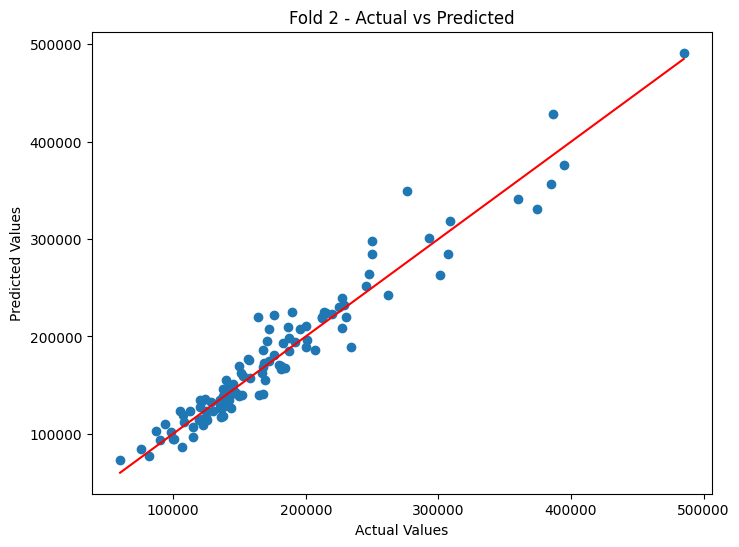

Fold 3
RMSE for Fold 3: 31334.228648479697


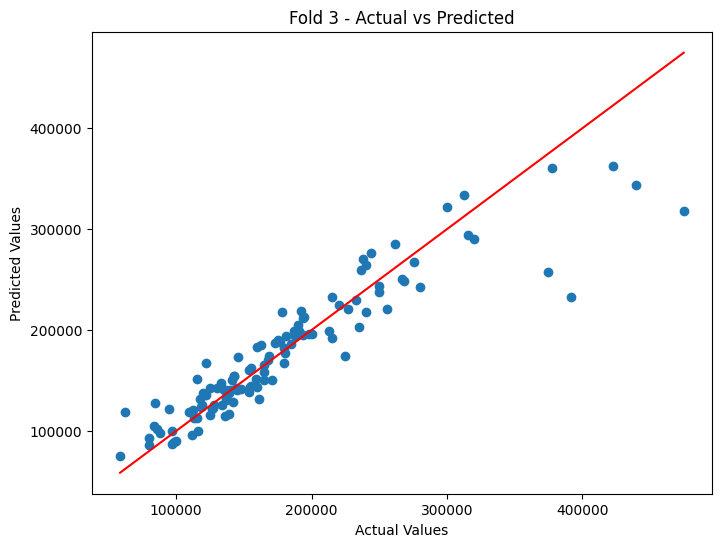

Fold 4
RMSE for Fold 4: 18955.49184370392


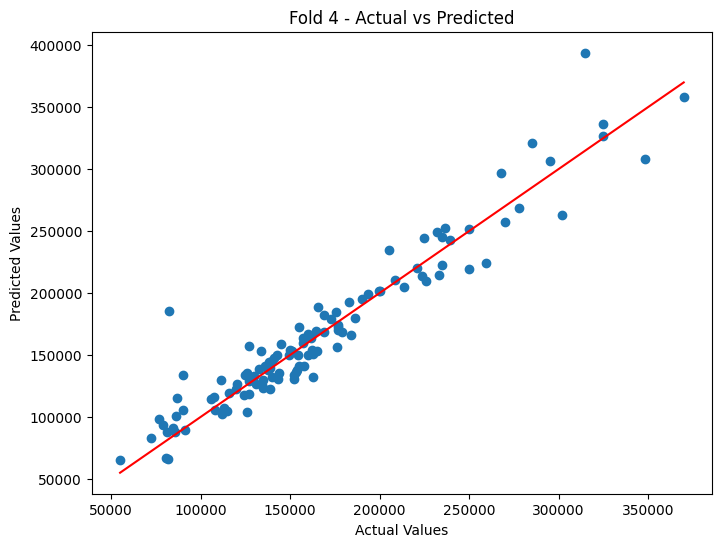

Fold 5
RMSE for Fold 5: 25356.288629376537


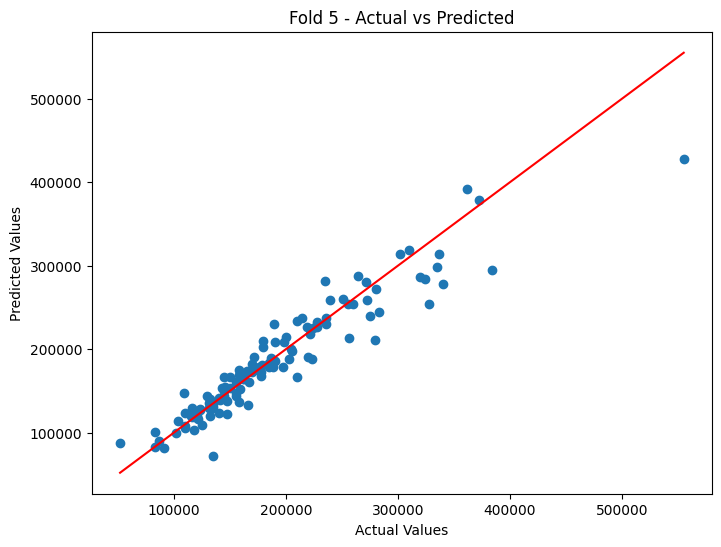

Fold 6
RMSE for Fold 6: 54681.82492605718


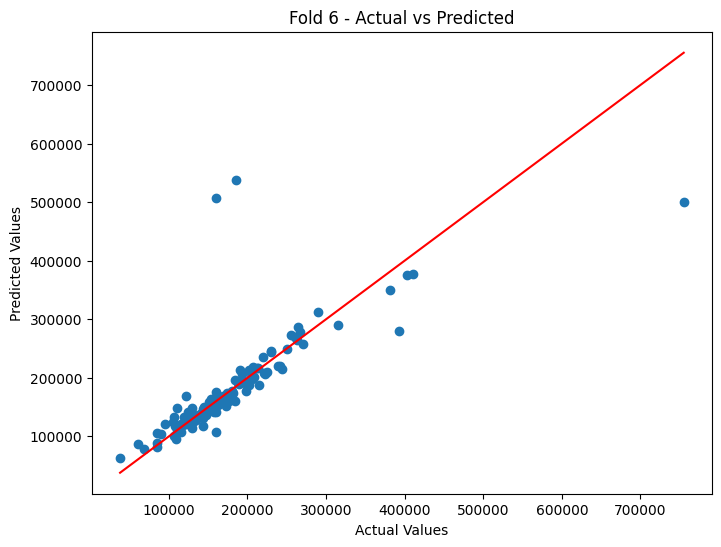

Fold 7
RMSE for Fold 7: 21777.20276010567


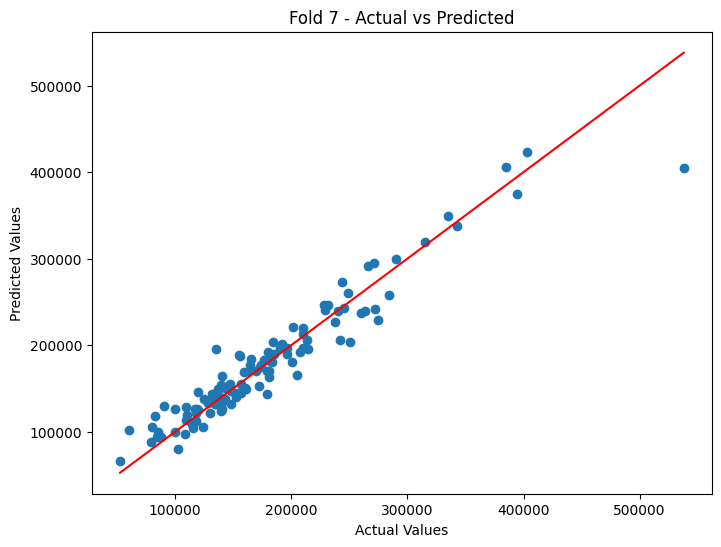

Fold 8
RMSE for Fold 8: 23059.04484144966


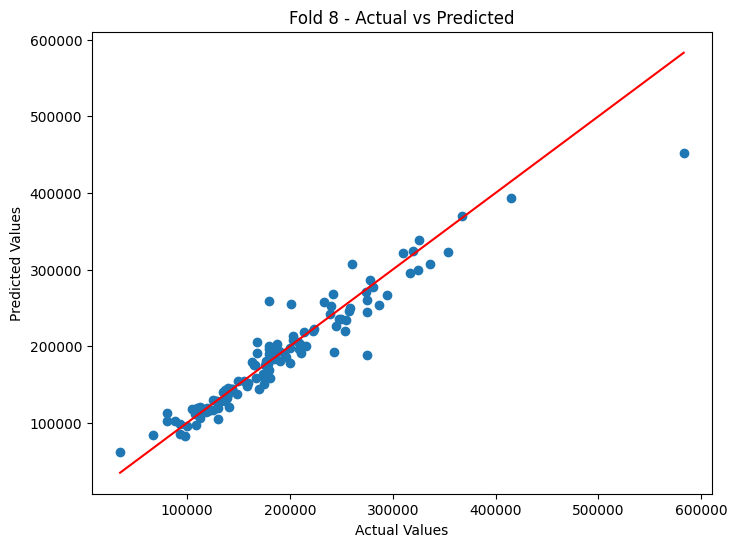

Fold 9
RMSE for Fold 9: 24844.876735563957


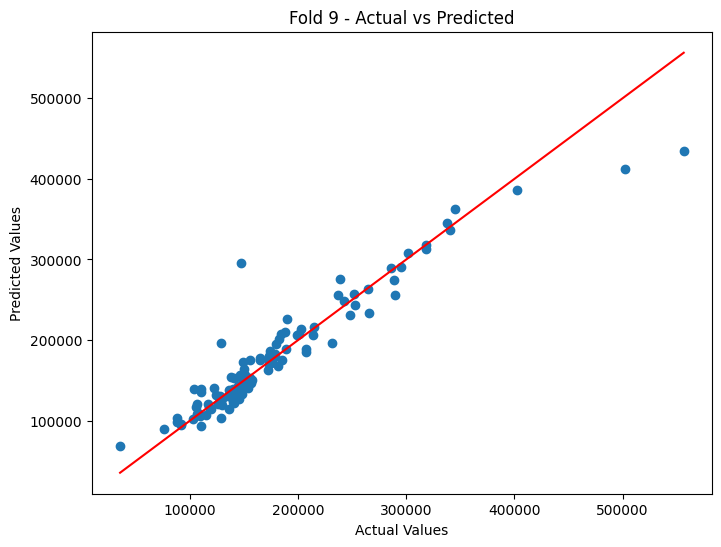

Fold 10
RMSE for Fold 10: 19165.687151535403


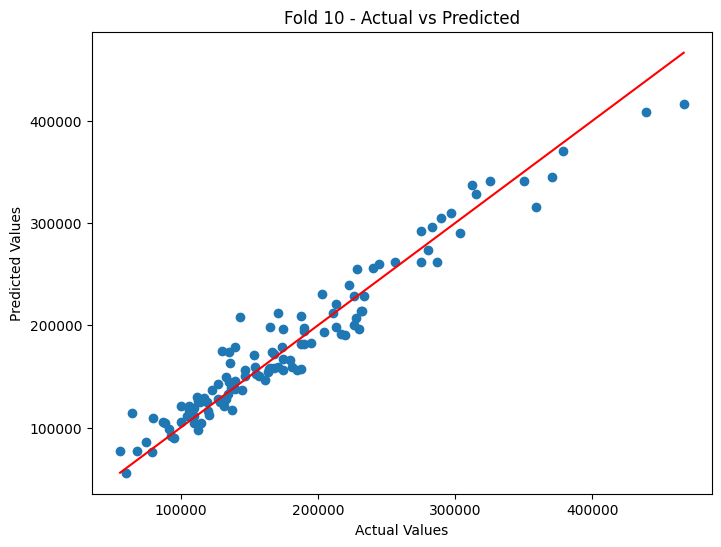

Average RMSE across 10 folds: 25862.8989436973


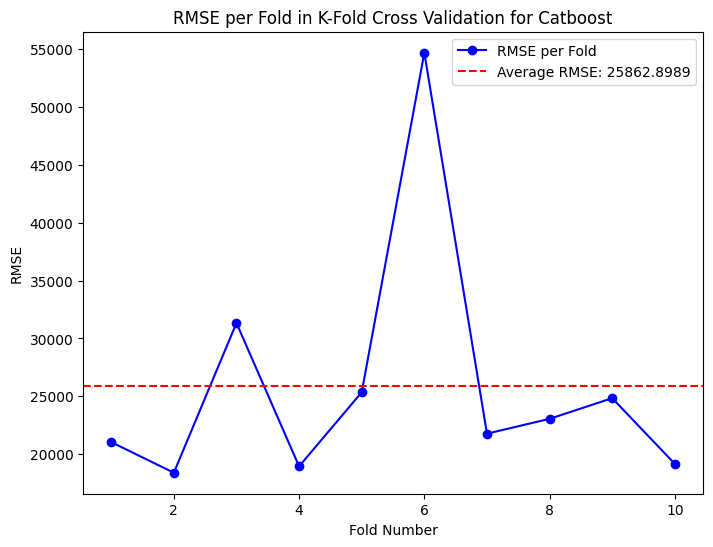

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Define the number of folds for k-fold cross-validation
n_splits = 10

# Initialize KFold
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)  # Set random_state for reproducibility

# List to store RMSE values for each fold
rmse_scores_catboost = []

# Iterate through the folds
fold_idx = 1
for train_index, test_index in kf.split(X_train):
    print(f"Fold {fold_idx}")

    # Split the data into training and validation sets for the current fold
    X_train_fold, X_val_fold = X_train[train_index], X_train[test_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[test_index]

    # Fit your model on the training data for this fold
    catboost_final.fit(X_train_fold, y_train_fold)

    # Make predictions on the validation set
    y_pred_fold = catboost_final.predict(X_val_fold)

    # Calculate evaluation metrics (e.g., RMSE) for this fold
    rmse_fold = np.sqrt(mean_squared_error(y_val_fold, y_pred_fold))
    rmse_scores_catboost.append(rmse_fold)
    print(f"RMSE for Fold {fold_idx}: {rmse_fold}")

    # Plot for current fold
    plt.figure(figsize=(8, 6))
    plt.scatter(y_val_fold, y_pred_fold)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Fold {fold_idx} - Actual vs Predicted')
    plt.plot([min(y_val_fold), max(y_val_fold)], [min(y_val_fold), max(y_val_fold)], color='red')
    plt.show()

    fold_idx += 1

# Calculate the average RMSE across all folds
average_rmse = np.mean(rmse_scores_catboost)
print(f"Average RMSE across {n_splits} folds: {average_rmse}")

# Plot RMSE values for each fold
plt.figure(figsize=(8, 6))
plt.plot(range(1, n_splits + 1), rmse_scores_catboost, marker='o', linestyle='-', color='blue', label='RMSE per Fold')
plt.axhline(y=average_rmse, color='red', linestyle='--', label=f'Average RMSE: {average_rmse:.4f}')
plt.xlabel('Fold Number')
plt.ylabel('RMSE')
plt.title('RMSE per Fold in K-Fold Cross Validation for Catboost')
plt.legend()
plt.show()


K fold cross validation **lightbgm**

Fold 1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001284 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3467
[LightGBM] [Info] Number of data points in the train set: 1051, number of used features: 129
[LightGBM] [Info] Start training from score 179033.439581


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


RMSE for Fold 1: 22849.3042637686


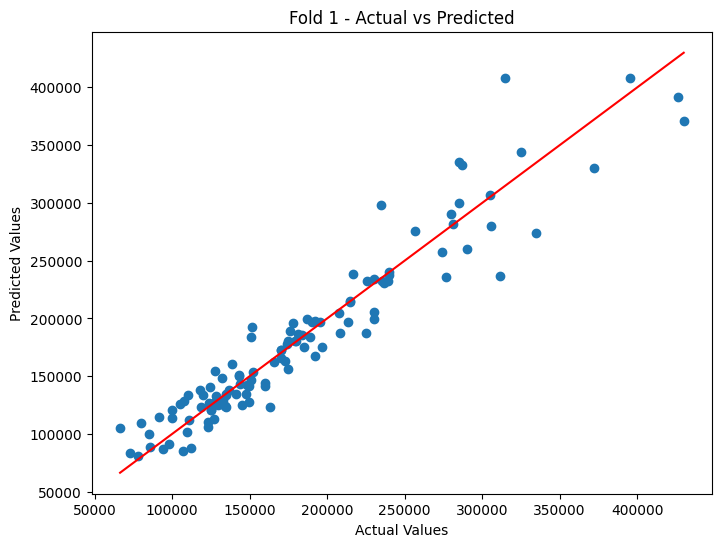

Fold 2
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001318 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3462
[LightGBM] [Info] Number of data points in the train set: 1051, number of used features: 129
[LightGBM] [Info] Start training from score 179634.424358


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


RMSE for Fold 2: 22479.666875136278


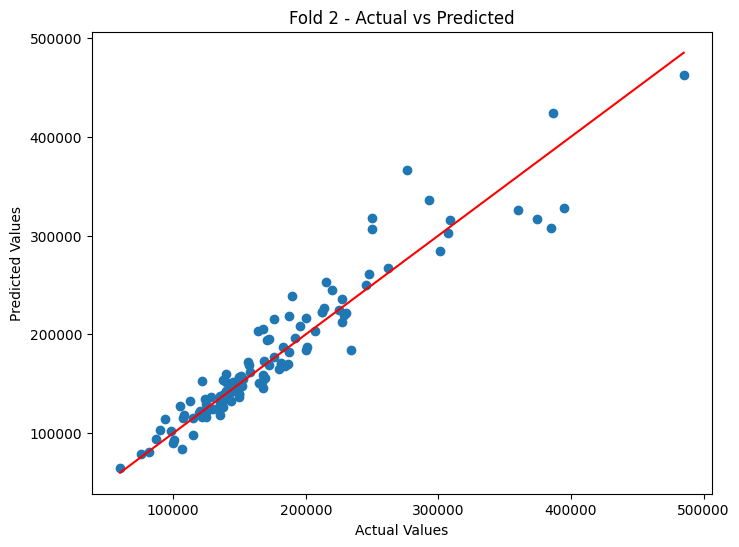

Fold 3
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001199 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3464
[LightGBM] [Info] Number of data points in the train set: 1051, number of used features: 127
[LightGBM] [Info] Start training from score 179188.864891


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


RMSE for Fold 3: 33042.673080356195


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


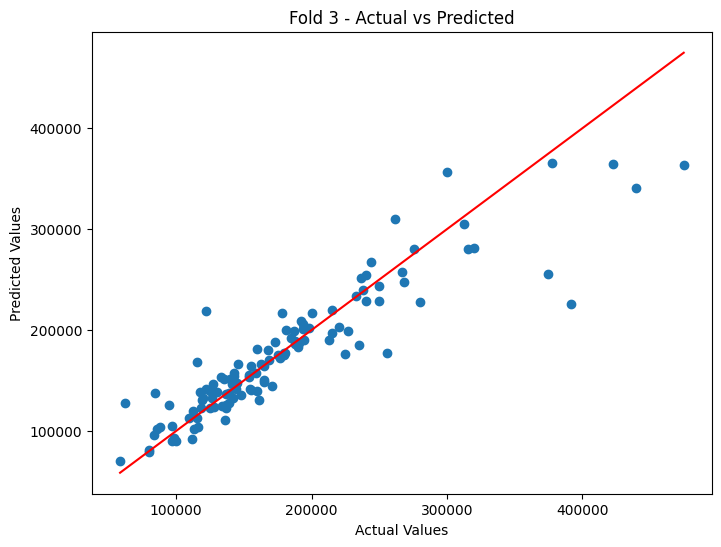

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fold 4
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001819 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3463
[LightGBM] [Info] Number of data points in the train set: 1051, number of used features: 128
[LightGBM] [Info] Start training from score 180700.895338
RMSE for Fold 4: 21509.233373855095


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


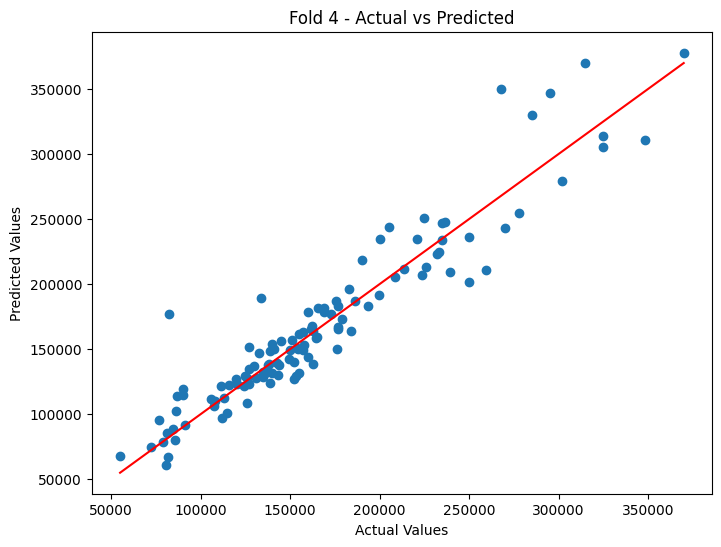

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fold 5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001407 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3458
[LightGBM] [Info] Number of data points in the train set: 1051, number of used features: 128
[LightGBM] [Info] Start training from score 178121.844910
RMSE for Fold 5: 27516.291322765956


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


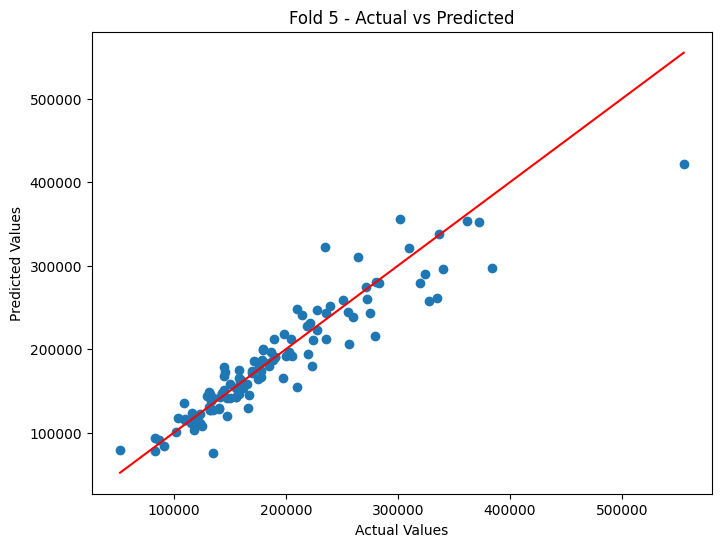

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fold 6
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001287 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3454
[LightGBM] [Info] Number of data points in the train set: 1051, number of used features: 128
[LightGBM] [Info] Start training from score 179407.446242
RMSE for Fold 6: 52166.786417201416


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


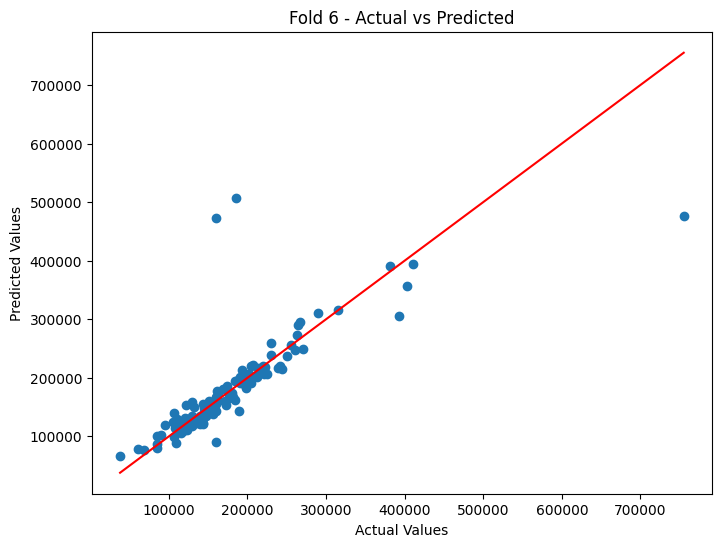

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fold 7
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000812 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3461
[LightGBM] [Info] Number of data points in the train set: 1051, number of used features: 125
[LightGBM] [Info] Start training from score 179483.284491
RMSE for Fold 7: 25423.47438234212


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


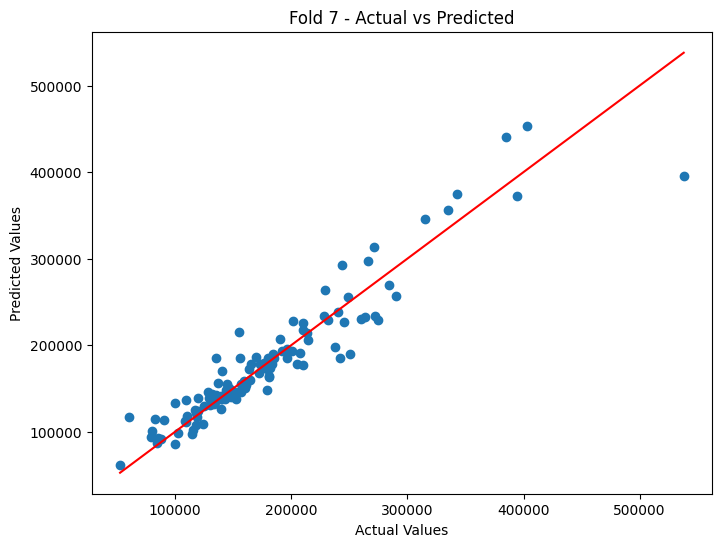

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fold 8
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000868 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3472
[LightGBM] [Info] Number of data points in the train set: 1051, number of used features: 130
[LightGBM] [Info] Start training from score 178050.284491
RMSE for Fold 8: 27172.628381092243


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


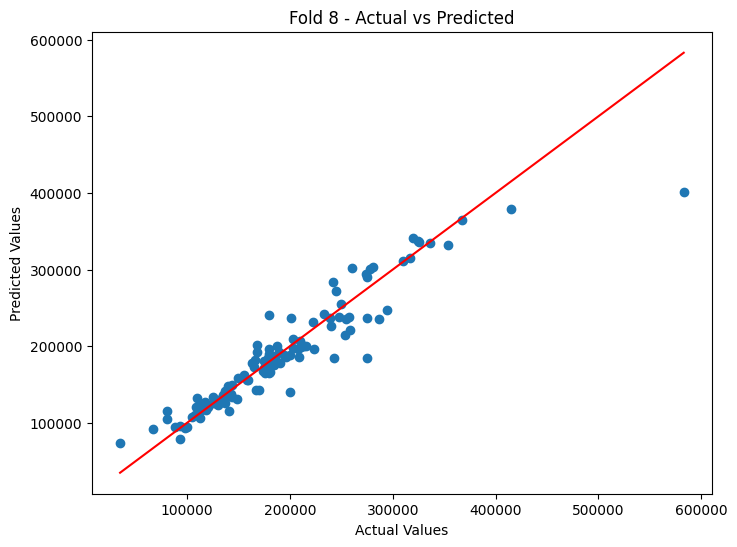

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fold 9
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001164 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3473
[LightGBM] [Info] Number of data points in the train set: 1052, number of used features: 131
[LightGBM] [Info] Start training from score 179419.130228
RMSE for Fold 9: 28131.501112949954


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


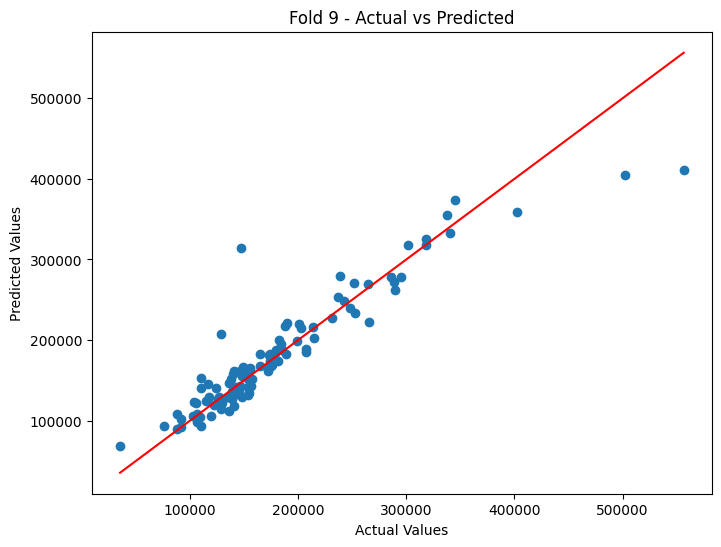

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fold 10
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001528 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3466
[LightGBM] [Info] Number of data points in the train set: 1052, number of used features: 129
[LightGBM] [Info] Start training from score 179334.272814
RMSE for Fold 10: 20576.886419672475


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


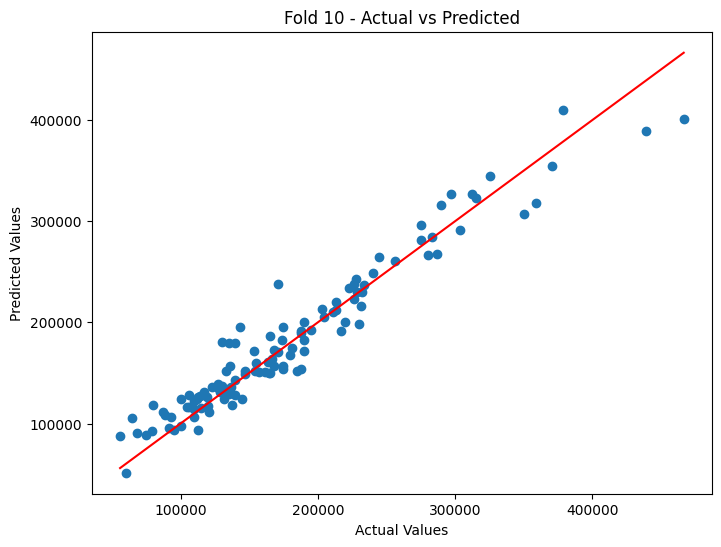

Average RMSE across 10 folds: 28086.84456291403


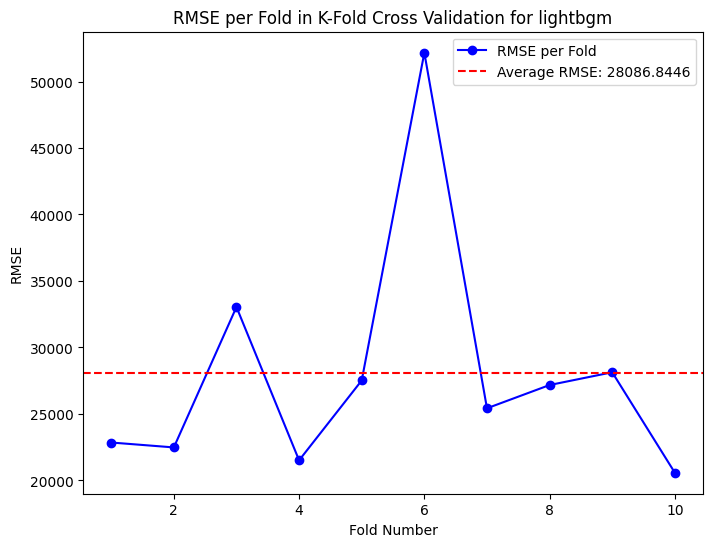

In [ ]:
from sklearn.model_selection import KFold

# Define the number of folds for k-fold cross-validation
n_splits = 10

# Initialize KFold
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)  # Set random_state for reproducibility

# List to store RMSE values for each fold
rmse_scores_lightbgm = []

# Iterate through the folds
fold_idx = 1
for train_index, test_index in kf.split(X_train):
    print(f"Fold {fold_idx}")

    # Split the data into training and validation sets for the current fold
    X_train_fold, X_val_fold = X_train[train_index], X_train[test_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[test_index]

    # Fit your model on the training data for this fold
    lgbm_final.fit(X_train_fold, y_train_fold)

    # Make predictions on the validation set
    y_pred_fold = lgbm_final.predict(X_val_fold)

    # Calculate evaluation metrics (e.g., RMSE) for this fold
    rmse_fold = np.sqrt(mean_squared_error(y_val_fold, y_pred_fold))
    rmse_scores_lightbgm.append(rmse_fold)
    print(f"RMSE for Fold {fold_idx}: {rmse_fold}")

    # Plot for current fold
    plt.figure(figsize=(8, 6))
    plt.scatter(y_val_fold, y_pred_fold)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Fold {fold_idx} - Actual vs Predicted')
    plt.plot([min(y_val_fold), max(y_val_fold)], [min(y_val_fold), max(y_val_fold)], color='red')
    plt.show()

    fold_idx += 1

# Calculate the average RMSE across all folds
average_rmse = np.mean(rmse_scores_lightbgm)
print(f"Average RMSE across {n_splits} folds: {average_rmse}")

# Plot RMSE values for each fold
plt.figure(figsize=(8, 6))
plt.plot(range(1, n_splits + 1), rmse_scores_lightbgm, marker='o', linestyle='-', color='blue', label='RMSE per Fold')
plt.axhline(y=average_rmse, color='red', linestyle='--', label=f'Average RMSE: {average_rmse:.4f}')
plt.xlabel('Fold Number')
plt.ylabel('RMSE')
plt.title('RMSE per Fold in K-Fold Cross Validation for lightbgm')
plt.legend()
plt.show()


Fold 1
RMSE for Fold 1: 21900.496414544086


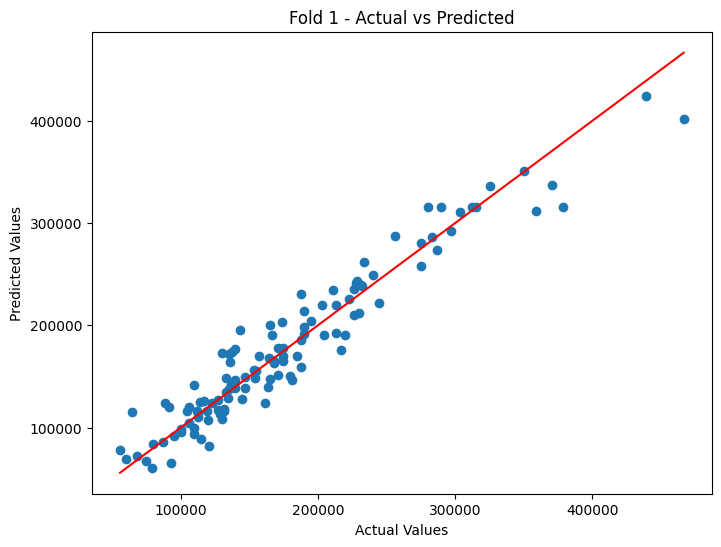

Fold 2
RMSE for Fold 2: 21652.52962978218


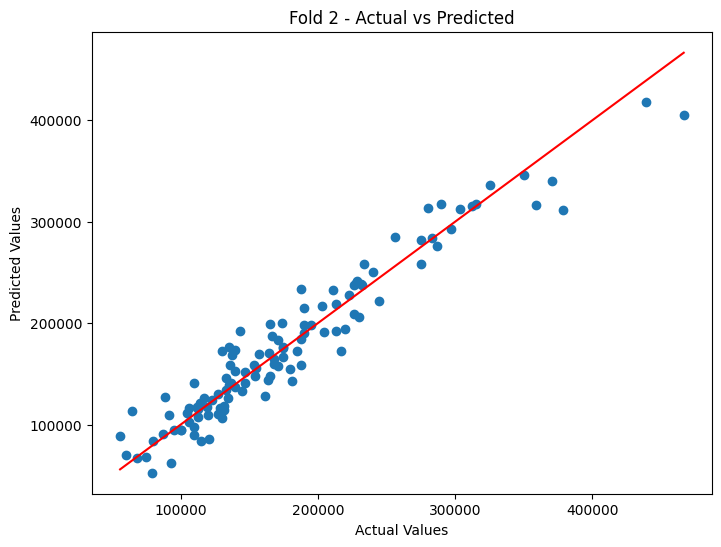

Fold 3
RMSE for Fold 3: 21881.448073908556


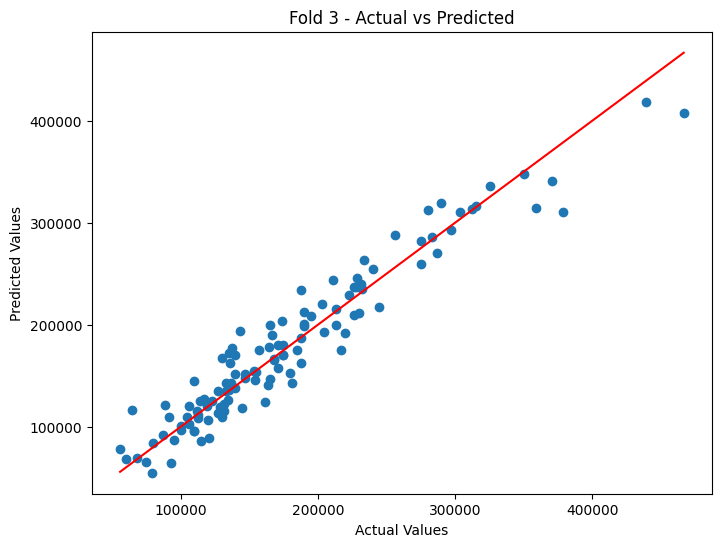

Fold 4
RMSE for Fold 4: 22013.9921980582


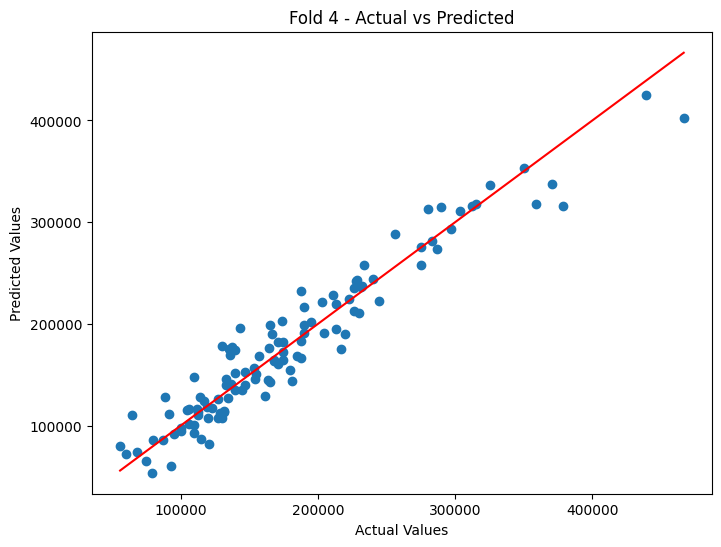

Fold 5
RMSE for Fold 5: 21869.129943534117


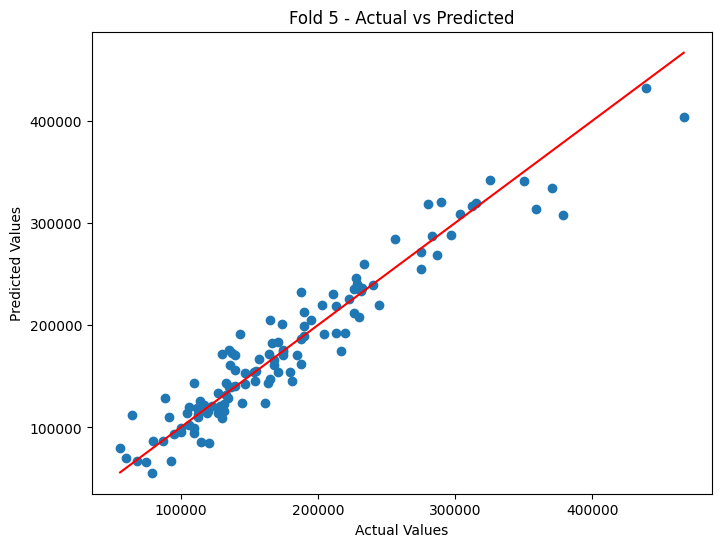

Fold 6
RMSE for Fold 6: 21723.250581014625


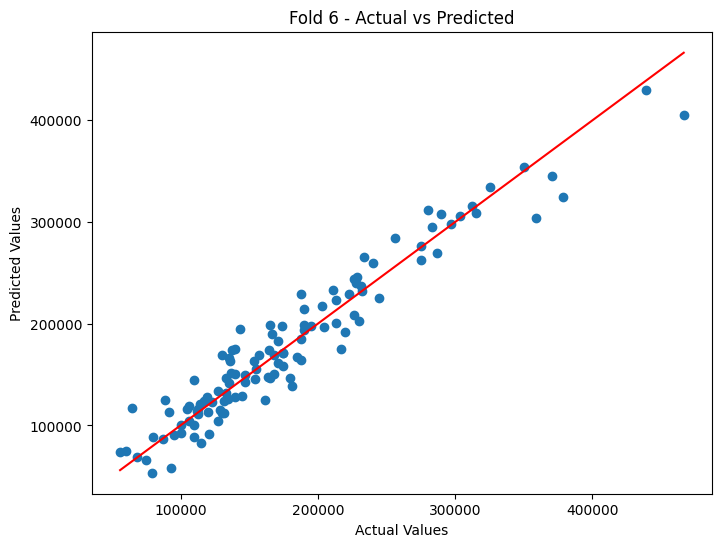

Fold 7
RMSE for Fold 7: 21566.88830189123


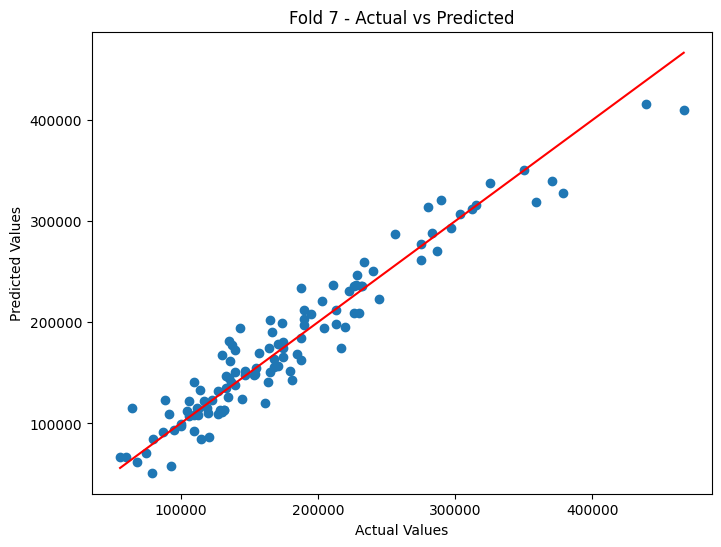

Fold 8
RMSE for Fold 8: 21543.355381534577


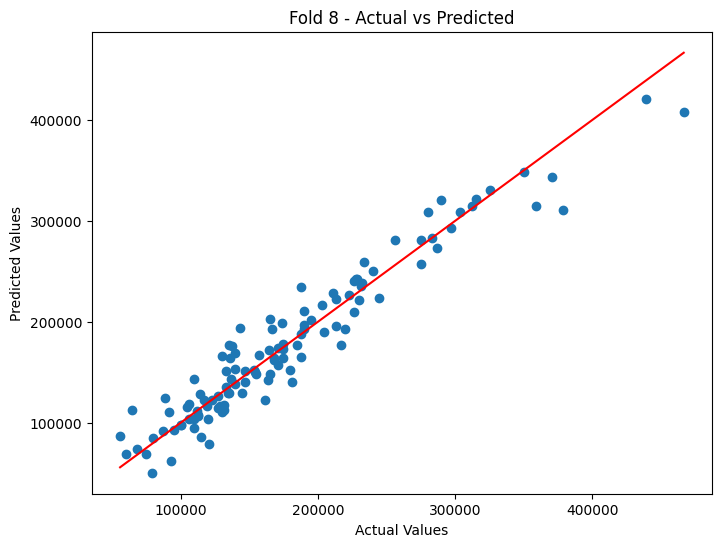

Fold 9
RMSE for Fold 9: 22037.226779175337


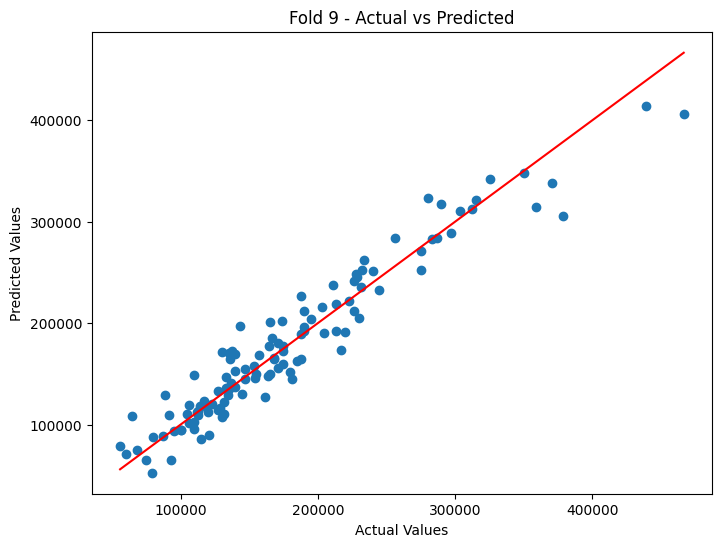

Fold 10
RMSE for Fold 10: 27671.72248160833


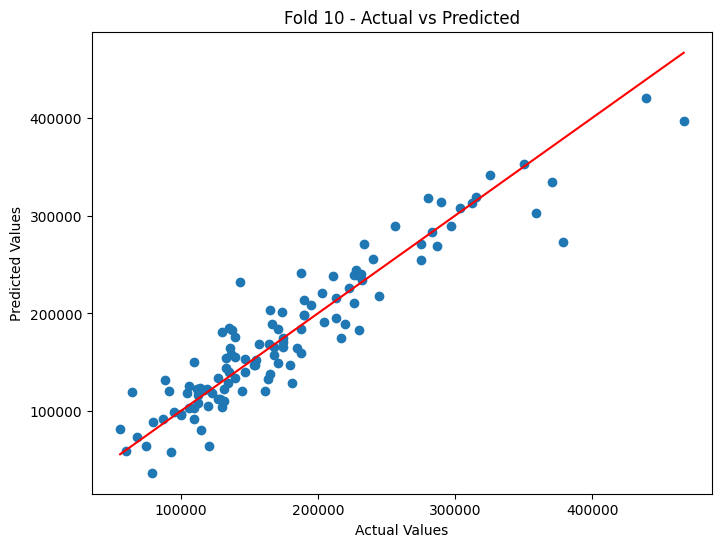

Average RMSE across 10 folds: 22386.003978505127


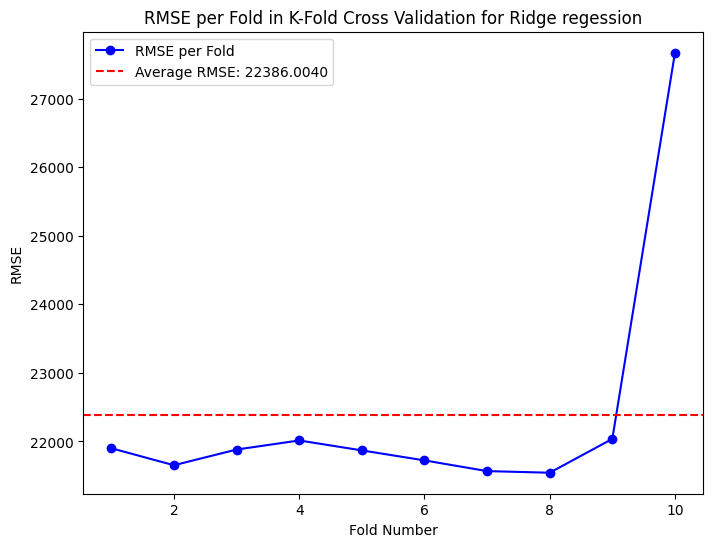

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Assuming X_train and y_train are defined from your previous code
# Example:
# X_train = ...  # Your training features
# y_train = ...  # Your training target variable

# Initialize Ridge Regression model
ridge = Ridge(alpha=1.0)  # You can adjust the alpha parameter

# Define the number of folds for k-fold cross-validation
n_splits = 10

# Initialize KFold
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store RMSE for each fold
rmse_scores_ridge = []

# Iterate through folds
fold_idx = 1
for train_index, val_index in kf.split(X_train):
    print(f"Fold {fold_idx}")

    X_train_fold, X_val_fold = X_train[train_index], X_train[test_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[test_index]

    # Fit the model on the current fold's training data
    ridge.fit(X_train_fold, y_train_fold)

    # Predict on the validation set
    y_pred_fold = ridge.predict(X_val_fold)

    # Calculate RMSE for the current fold
    rmse_fold = np.sqrt(mean_squared_error(y_val_fold, y_pred_fold))
    rmse_scores_ridge.append(rmse_fold)
    print(f"RMSE for Fold {fold_idx}: {rmse_fold}")

    # Plot for the current fold (optional)
    plt.figure(figsize=(8, 6))
    plt.scatter(y_val_fold, y_pred_fold)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Fold {fold_idx} - Actual vs Predicted')
    plt.plot([min(y_val_fold), max(y_val_fold)], [min(y_val_fold), max(y_val_fold)], color='red')
    plt.show()
    fold_idx += 1

# Calculate and print average RMSE
avg_rmse = np.mean(rmse_scores_ridge)
print(f"Average RMSE across {n_splits} folds: {avg_rmse}")

# Plot RMSE scores (optional)
plt.figure(figsize=(8, 6))
plt.plot(range(1, n_splits + 1), rmse_scores_ridge, marker='o', linestyle='-', color='blue', label='RMSE per Fold')
plt.axhline(y=avg_rmse, color='red', linestyle='--', label=f'Average RMSE: {avg_rmse:.4f}')
plt.xlabel('Fold Number')
plt.ylabel('RMSE')
plt.title('RMSE per Fold in K-Fold Cross Validation for Ridge regession')
plt.legend()
plt.show()


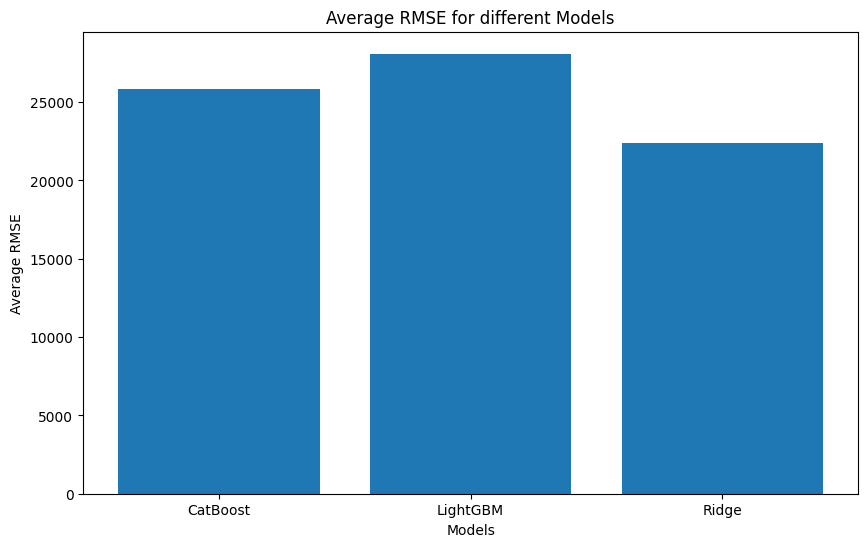

In [ ]:
import matplotlib.pyplot as plt

# Assuming rmse_scores for each model are stored in these lists:
# Replace these with your actual RMSE score lists
rmse_scores_catboost = rmse_scores_catboost  # Example: [0.1, 0.12, 0.09]
rmse_scores_lightgbm = rmse_scores_lightbgm # Example: [0.11, 0.13, 0.10]
rmse_scores_ridge = rmse_scores_ridge # Example: [0.15, 0.16, 0.14]

# Model names
model_names = ['CatBoost', 'LightGBM', 'Ridge']

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(model_names, [np.mean(rmse_scores_catboost), np.mean(rmse_scores_lightgbm), np.mean(rmse_scores_ridge)])
plt.xlabel('Models')
plt.ylabel('Average RMSE')
plt.title('Average RMSE for different Models')
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Model,MAE,RMSE,R2 Score
3,CatBoost,15851.088842,28582.640496,0.894592
4,Ensemble Model,16547.793788,31089.274812,0.875293
0,XGBoost,17077.699219,31297.293429,0.873619
2,LightGBM,17785.847485,31522.440799,0.871794
1,Ridge Regression,24890.218291,40834.177989,0.784863


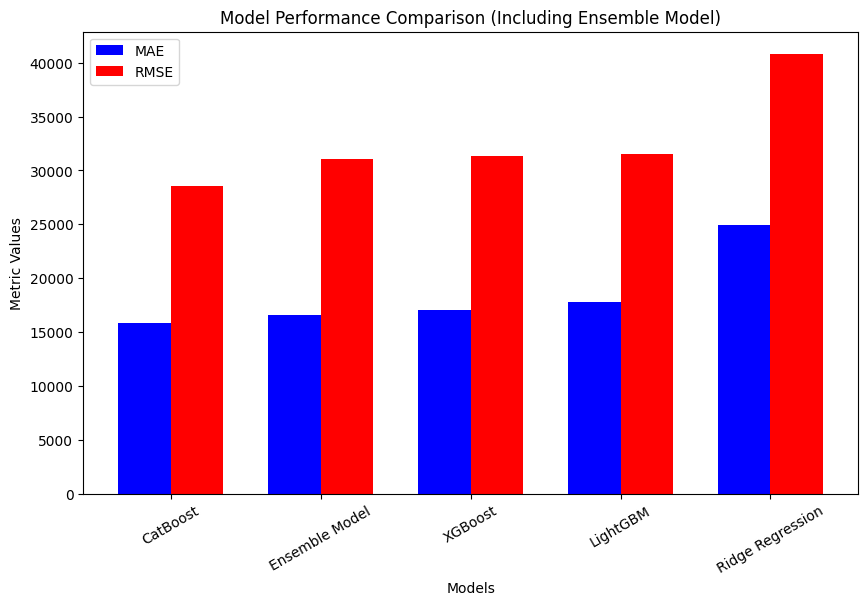

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define a function to evaluate and plot model performance on test data
def evaluate_models(models, X_test, y_test):
    results = []
    model_preds = []  # Store predictions for ensemble

    for model_name, model in models.items():
        # Predict on test data
        y_pred = model.predict(X_test)
        model_preds.append(y_pred)  # Store predictions for ensemble

        # Calculate evaluation metrics
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        # Append results
        results.append([model_name, mae, rmse, r2])

    # **Ensemble Model (Averaging Predictions)**
    y_ensemble_pred = np.mean(np.column_stack(model_preds), axis=1)

    # Compute metrics for the ensemble model
    ensemble_mae = mean_absolute_error(y_test, y_ensemble_pred)
    ensemble_rmse = np.sqrt(mean_squared_error(y_test, y_ensemble_pred))
    ensemble_r2 = r2_score(y_test, y_ensemble_pred)

    # Append ensemble model results
    results.append(["Ensemble Model", ensemble_mae, ensemble_rmse, ensemble_r2])

    # Convert to DataFrame
    results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score"])
    results_df.sort_values(by="RMSE", inplace=True)  # Sorting by RMSE for better visualization

    # Display results
    display(results_df)

    # Extracting values for plotting
    models_list = results_df["Model"]
    mae_values = results_df["MAE"]
    rmse_values = results_df["RMSE"]

    # Plotting MAE and RMSE
    x = np.arange(len(models_list))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.bar(x - width/2, mae_values, width, label="MAE", color="blue")
    ax.bar(x + width/2, rmse_values, width, label="RMSE", color="red")

    ax.set_xlabel("Models")
    ax.set_ylabel("Metric Values")
    ax.set_title("Model Performance Comparison (Including Ensemble Model)")
    ax.set_xticks(x)
    ax.set_xticklabels(models_list, rotation=30)
    ax.legend()

    plt.show()

# Create a dictionary with your models
models = {
    "XGBoost": xgb_final,
    "Ridge Regression": ridge_final,
    "LightGBM": lgbm_final,
    "CatBoost": catboost_final
}

# Call the evaluation function
evaluate_models(models, X_test, y_test)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define a function to evaluate and plot model performance on test data
def evaluate_models(models, X_test, y_test):
    results = []
    classification_results = []
    model_preds = []  # Store predictions for ensemble

    for model_name, model in models.items():
        # Predict on test data
        y_pred = model.predict(X_test)
        model_preds.append(y_pred)  # Store predictions for ensemble
        y_pred_class = np.round(y_pred)  # Convert probabilities to class labels if needed

        # Calculate regression evaluation metrics
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        # Calculate classification evaluation metrics
        accuracy = accuracy_score(y_test, y_pred_class)
        precision = precision_score(y_test, y_pred_class, average='binary')
        recall = recall_score(y_test, y_pred_class, average='binary')
        f1 = f1_score(y_test, y_pred_class, average='binary')

        # Append regression results
        results.append([model_name, mae, rmse, r2])

        # Append classification results
        classification_results.append([model_name, accuracy, precision, recall, f1])

        # Plot Confusion Matrix
        cm = confusion_matrix(y_test, y_pred_class)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix for {model_name}")
        plt.show()

    # **Ensemble Model (Averaging Predictions)**
    y_ensemble_pred = np.mean(np.column_stack(model_preds), axis=1)
    y_ensemble_class = np.round(y_ensemble_pred)

    # Compute regression metrics for the ensemble model
    ensemble_mae = mean_absolute_error(y_test, y_ensemble_pred)
    ensemble_rmse = np.sqrt(mean_squared_error(y_test, y_ensemble_pred))
    ensemble_r2 = r2_score(y_test, y_ensemble_pred)

    # Compute classification metrics for the ensemble model
    ensemble_accuracy = accuracy_score(y_test, y_ensemble_class)
    ensemble_precision = precision_score(y_test, y_ensemble_class, average='binary')
    ensemble_recall = recall_score(y_test, y_ensemble_class, average='binary')
    ensemble_f1 = f1_score(y_test, y_ensemble_class, average='binary')

    # Append ensemble model results
    results.append(["Ensemble Model", ensemble_mae, ensemble_rmse, ensemble_r2])
    classification_results.append(["Ensemble Model", ensemble_accuracy, ensemble_precision, ensemble_recall, ensemble_f1])

    # Convert to DataFrame
    results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score"])
    results_df.sort_values(by="RMSE", inplace=True)  # Sorting by RMSE for better visualization

    classification_results_df = pd.DataFrame(classification_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])

    # Display results
    display(results_df)
    display(classification_results_df)

    # Extracting values for plotting
    models_list = results_df["Model"]
    mae_values = results_df["MAE"]
    rmse_values = results_df["RMSE"]
    accuracy_values = classification_results_df["Accuracy"]

    # Plotting MAE and RMSE
    x = np.arange(len(models_list))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, mae_values, width, label="MAE", color="blue")
    ax.bar(x + width/2, rmse_values, width, label="RMSE", color="red")
    ax.set_xlabel("Models")
    ax.set_ylabel("Metric Values")
    ax.set_title("Model Performance Comparison (Including Ensemble Model)")
    ax.set_xticks(x)
    ax.set_xticklabels(models_list, rotation=30)
    ax.legend()
    plt.show()

    # Plotting Accuracy for Classification Models
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(models_list, accuracy_values, color="green", label="Accuracy")
    ax.set_xlabel("Models")
    ax.set_ylabel("Accuracy")
    ax.set_title("Classification Model Accuracy Comparison")
    ax.set_xticklabels(models_list, rotation=30)
    ax.legend()
    plt.show()

# Create a dictionary with your models
models = {
    "XGBoost": xgb_final,
    "Ridge Regression": ridge_final,
    "LightGBM": lgbm_final,
    "CatBoost": catboost_final
}

# Call the evaluation function
evaluate_models(models, X_test, y_test)


ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define a function to evaluate and plot model performance on test data
def evaluate_models(models, X_test, y_test):
    results = []
    model_preds = []  # Store predictions for ensemble

    for model_name, model in models.items():
        # Predict on test data
        y_pred = model.predict(X_test)
        model_preds.append(y_pred)  # Store predictions for ensemble
        # Instead of rounding, if you want class predictions for accuracy, do:
        # y_pred_class = np.where(y_pred > threshold, 1, 0)  # Set a threshold

        # Calculate regression evaluation metrics
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        # Append regression results
        results.append([model_name, mae, rmse, r2])

        # Instead of inappropriate classification metrics, you can plot residuals
        # residuals = y_test - y_pred
        # plt.figure(figsize=(8, 6))
        # sns.histplot(residuals, bins=30)
        # plt.title(f"Residuals for {model_name}")
        # plt.xlabel("Residuals")
        # plt.ylabel("Frequency")
        # plt.show()

    # **Ensemble Model (Averaging Predictions)**
    y_ensemble_pred = np.mean(np.column_stack(model_preds), axis=1)

    # Compute regression metrics for the ensemble model
    ensemble_mae = mean_absolute_error(y_test, y_ensemble_pred)
    ensemble_rmse = np.sqrt(mean_squared_error(y_test, y_ensemble_pred))
    ensemble_r2 = r2_score(y_test, y_ensemble_pred)

    # Append ensemble model results
    results.append(["Ensemble Model", ensemble_mae, ensemble_rmse, ensemble_r2])

    # Convert to DataFrame
    results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score"])
    results_df.sort_values(by="RMSE", inplace=True)  # Sorting by RMSE for better visualization

    # Display results
    display(results_df)
      models_list = results_df["Model"]
    mae_values = results_df["MAE"]
    rmse_values = results_df["RMSE"]
    accuracy_values = classification_results_df["Accuracy"]

    # Plotting MAE and RMSE
    x = np.arange(len(models_list))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, mae_values, width, label="MAE", color="blue")
    ax.bar(x + width/2, rmse_values, width, label="RMSE", color="red")
    ax.set_xlabel("Models")
    ax.set_ylabel("Metric Values")
    ax.set_title("Model Performance Comparison (Including Ensemble Model)")
    ax.set_xticks(x)
    ax.set_xticklabels(models_list, rotation=30)
    ax.legend()
    plt.show()

    # Plotting Accuracy for Classification Models
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(models_list, accuracy_values, color="green", label="Accuracy")
    ax.set_xlabel("Models")
    ax.set_ylabel("Accuracy")
    ax.set_title("Classification Model Accuracy Comparison")
    ax.set_xticklabels(models_list, rotation=30)
    ax.legend()
    plt.show()

# Create a dictionary with your models
models = {
    "XGBoost": xgb_final,
    "Ridge Regression": ridge_final,
    "LightGBM": lgbm_final,
    "CatBoost": catboost_final
}

# Call the evaluation function
evaluate_models(models, X_test, y_test)

    # ... (rest of the plotting code for MAE and RMSE)

IndentationError: unexpected indent (<ipython-input-66-1150d05cc6b1>, line 53)

In [ ]:
from sklearn.metrics import mean_squared_error

# Voting Regressor RMSE
y_pred_voting = vr.predict(X_test)  # Assuming 'vr' is your Voting Regressor
# Calculate MSE and then take the square root for RMSE manually
mse_voting = mean_squared_error(y_test, y_pred_voting)
rmse_voting = np.sqrt(mse_voting)
print(f"Voting Regressor RMSE: {rmse_voting}")

# Stacking Regressor RMSE
y_pred_stacking = stackreg.predict(X_test)  # Assuming 'stackreg' is your Stacking Regressor
# Calculate MSE and then take the square root for RMSE manually
mse_stacking = mean_squared_error(y_test, y_pred_stacking)
rmse_stacking = np.sqrt(mse_stacking)
print(f"Stacking Regressor with XGBRegressor RMSE: {rmse_stacking}")

In [ ]:
from sklearn.ensemble import StackingRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming you already have individual models defined as rfr_final, xgb_final, ridge_final, lgbm_final, catboost_final

# Define the Voting Regressor with custom weights if needed
voting_regressor = VotingRegressor(
    estimators=[
        ('xgb', xgb_final),
        ('ridge', ridge_final),
        ('lgbm', lgbm_final),
        ('cat', catboost_final)
    ],
    weights=[2, 1, 1, 1]  # Example weights, adjust based on model performance
)

# Fit the Voting Regressor
voting_regressor.fit(X_train, y_train)

# Define the Stacking Regressor with the Voting Regressor as the final estimator
stacking_regressor = StackingRegressor(
    estimators=[
        ('xgb', xgb_final),
        ('ridge', ridge_final),
        ('lgbm', lgbm_final),
        ('cat', catboost_final)
    ],
    final_estimator=voting_regressor  # Voting Regressor as the final estimator
)

# Fit the Stacking Regressor
stacking_regressor.fit(X_train, y_train)

# Predict on test set
y_pred_stack = stacking_regressor.predict(X_test)

# Calculate evaluation metrics
mae_stack = mean_absolute_error(y_test, y_pred_stack)
mse_stack = mean_squared_error(y_test, y_pred_stack)  # Calculate MSE
rmse_stack = np.sqrt(mse_stack)
r2_stack = r2_score(y_test, y_pred_stack)

# Print the results
print(f"MAE of the Stacking Regressor with Voting Regressor: {mae_stack}")
print(f"RMSE of the Stacking Regressor with Voting Regressor: {rmse_stack}")
print(f"R² of the Stacking Regressor with Voting Regressor: {r2_stack}")


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define a function to evaluate and compare models (including Ensemble)
def evaluate_models(models, X_test, y_test):
    results = []
    model_preds = []  # Store predictions for ensemble

    for model_name, model in models.items():
        # Predict on test data
        y_pred = model.predict(X_test)
        model_preds.append(y_pred)  # Store predictions for ensemble

        # Calculate evaluation metrics
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        # Append results
        results.append([model_name, mae, rmse, r2])

    # **Ensemble Model (Averaging Predictions)**
    y_ensemble_pred = np.mean(np.column_stack(model_preds), axis=1)

    # Compute metrics for the ensemble model
    ensemble_mae = mean_absolute_error(y_test, y_ensemble_pred)
    ensemble_rmse = np.sqrt(mean_squared_error(y_test, y_ensemble_pred))
    ensemble_r2 = r2_score(y_test, y_ensemble_pred)

    # Append ensemble model results
    results.append(["Ensemble Model", ensemble_mae, ensemble_rmse, ensemble_r2])

    # Convert to DataFrame
    results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score"])
    results_df.sort_values(by="RMSE", inplace=True)  # Sorting by RMSE for better visualization

    # Display results
    display(results_df)

    # Extracting values for plotting
    models_list = results_df["Model"]
    mae_values = results_df["MAE"]
    rmse_values = results_df["RMSE"]

    # Plotting MAE and RMSE
    x = np.arange(len(models_list))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.bar(x - width/2, mae_values, width, label="MAE", color="blue")
    ax.bar(x + width/2, rmse_values, width, label="RMSE", color="red")

    ax.set_xlabel("Models")
    ax.set_ylabel("Metric Values")
    ax.set_title("Model Performance Comparison (Including Ensemble Model)")
    ax.set_xticks(x)
    ax.set_xticklabels(models_list, rotation=30)
    ax.legend()

    plt.show()

    # **Comparison of Ensemble Model with Others**
    fig, ax = plt.subplots(figsize=(12, 6))

    # Difference in RMSE and MAE compared to the ensemble model
    mae_diff = mae_values - ensemble_mae
    rmse_diff = rmse_values - ensemble_rmse

    ax.plot(models_list, mae_diff, marker='o', linestyle='-', color='blue', label="MAE Difference")
    ax.plot(models_list, rmse_diff, marker='s', linestyle='-', color='red', label="RMSE Difference")

    ax.axhline(0, color='gray', linestyle="--", linewidth=1)  # Baseline for ensemble comparison

    ax.set_xlabel("Models")
    ax.set_ylabel("Difference from Ensemble Model")
    ax.set_title("Performance Difference (Lower is Better)")
    ax.legend()
    plt.xticks(rotation=30)

    plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define a function to evaluate and compare models (including Ensemble)
def evaluate_models(models, X_test, y_test):
    results = []
    model_preds = []  # Store predictions for ensemble

    for model_name, model in models.items():
        # Predict on test data
        y_pred = model.predict(X_test)
        model_preds.append(y_pred)  # Store predictions for ensemble

        # Calculate evaluation metrics
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        # Append results
        results.append([model_name, mae, rmse, r2])

    # **Ensemble Model (Averaging Predictions)**
    y_ensemble_pred = np.mean(np.column_stack(model_preds), axis=1)

    # Compute metrics for the ensemble model
    ensemble_mae = mean_absolute_error(y_test, y_ensemble_pred)
    ensemble_rmse = np.sqrt(mean_squared_error(y_test, y_ensemble_pred))
    ensemble_r2 = r2_score(y_test, y_ensemble_pred)

    # Append ensemble model results
    results.append(["Ensemble Model", ensemble_mae, ensemble_rmse, ensemble_r2])

    # Convert to DataFrame
    results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score"])
    results_df.sort_values(by="RMSE", inplace=True)  # Sorting by RMSE for better visualization

    # Display results
    print("\nModel Performance Comparison:")
    print(results_df)

    # Extracting values for plotting
    models_list = results_df["Model"]
    mae_values = results_df["MAE"]
    rmse_values = results_df["RMSE"]

    # **Ensure there is data before plotting**
    if len(models_list) > 0:
        # Plotting MAE and RMSE
        x = np.arange(len(models_list))
        width = 0.35

        plt.figure(figsize=(12, 6))
        plt.bar(x - width/2, mae_values, width, label="MAE", color="blue")
        plt.bar(x + width/2, rmse_values, width, label="RMSE", color="red")

        plt.xlabel("Models")
        plt.ylabel("Metric Values")
        plt.title("Model Performance Comparison (Including Ensemble Model)")
        plt.xticks(x, models_list, rotation=30)
        plt.legend()
        plt.show()

        # **Comparison of Ensemble Model with Others**
        plt.figure(figsize=(12, 6))

        # Difference in RMSE and MAE compared to the ensemble model
        mae_diff = mae_values - ensemble_mae
        rmse_diff = rmse_values - ensemble_rmse

        plt.plot(models_list, mae_diff, marker='o', linestyle='-', color='blue', label="MAE Difference")
        plt.plot(models_list, rmse_diff, marker='s', linestyle='-', color='red', label="RMSE Difference")

        plt.axhline(0, color='gray', linestyle="--", linewidth=1)  # Baseline for ensemble comparison

        plt.xlabel("Models")
        plt.ylabel("Difference from Ensemble Model")
        plt.title("Performance Difference (Lower is Better)")
        plt.legend()
        plt.xticks(rotation=30)
        plt.show()
    else:
        print("No models available for plotting.")

# Create a dictionary with your models
models = {
    "XGBoost": xgb_final,
    "Ridge Regression": ridge_final,
    "LightGBM": lgbm_final,
    "CatBoost": catboost_final
}

# Call the evaluation function
evaluate_models(models, X_test, y_test)


In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mode  # For majority voting

# Function to evaluate classification models with Maximum Voting
def evaluate_classification_models(models, X_test, y_test):
    results = []
    model_preds = []  # Store individual model predictions

    for model_name, model in models.items():
        # Predict on test data
        y_pred = model.predict(X_test)
        model_preds.append(y_pred)  # Store predictions

        # Calculate accuracy
        accuracy = accuracy_score(y_test, y_pred)

        # Append results
        results.append([model_name, accuracy])

    # **Ensemble Model (Majority Voting)**
    y_ensemble_pred = mode(np.column_stack(model_preds), axis=1).mode.flatten()

    # Compute accuracy for the ensemble model
    ensemble_accuracy = accuracy_score(y_test, y_ensemble_pred)

    # Append ensemble model results
    results.append(["Ensemble Model (Voting)", ensemble_accuracy])

    # Convert to DataFrame
    results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
    results_df.sort_values(by="Accuracy", ascending=False, inplace=True)

    # Display results
    print("\nModel Performance Comparison (Accuracy):")
    print(results_df)

    # **Plot Accuracy Comparison**
    plt.figure(figsize=(10, 6))
    plt.bar(results_df["Model"], results_df["Accuracy"], color="blue")
    plt.xlabel("Models")
    plt.ylabel("Accuracy Score")
    plt.title("Model Performance Comparison (Including Ensemble Voting)")
    plt.xticks(rotation=30)
    plt.show()

# Example: Replace with your classification models
models = {
    "XGBoost": xgb_final,
    "Ridge Regression": ridge_final,
    "LightGBM": lgbm_final,
    "CatBoost": catboost_final
}

# Call the evaluation function for classification models
evaluate_classification_models(models, X_test, y_test)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define a function to evaluate and compare models (including Ensemble)
def evaluate_models(models, X_test, y_test):
    results = []
    model_preds = []  # Store predictions for ensemble

    for model_name, model in models.items():
        # Predict on test data
        y_pred = model.predict(X_test)
        model_preds.append(y_pred)  # Store predictions for ensemble

        # Calculate evaluation metrics
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        # Append results
        results.append([model_name, mae, rmse, r2])

    # **Ensemble Model (Averaging Predictions)**
    y_ensemble_pred = np.mean(np.column_stack(model_preds), axis=1)

    # Compute metrics for the ensemble model
    ensemble_mae = mean_absolute_error(y_test, y_ensemble_pred)
    ensemble_rmse = np.sqrt(mean_squared_error(y_test, y_ensemble_pred))
    ensemble_r2 = r2_score(y_test, y_ensemble_pred)

    # Append ensemble model results
    results.append(["Ensemble Model", ensemble_mae, ensemble_rmse, ensemble_r2])

    # Convert to DataFrame
    results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score"])
    results_df.sort_values(by="RMSE", inplace=True)  # Sorting by RMSE for better visualization

    # Display results
    print("\nModel Performance Comparison:")
    print(results_df)

    # Extracting values for plotting
    models_list = results_df["Model"]
    mae_values = results_df["MAE"]
    rmse_values = results_df["RMSE"]

    # **Ensure there is data before plotting**
    if len(models_list) > 0:
        # Plotting MAE and RMSE
        x = np.arange(len(models_list))
        width = 0.35

        plt.figure(figsize=(12, 6))
        plt.bar(x - width/2, mae_values, width, label="MAE", color="blue")
        plt.bar(x + width/2, rmse_values, width, label="RMSE", color="red")

        plt.xlabel("Models")
        plt.ylabel("Metric Values")
        plt.title("Model Performance Comparison (Including Ensemble Model)")
        plt.xticks(x, models_list, rotation=30)
        plt.legend()
        plt.show()
    else:
        print("No models available for plotting.")

# Create a dictionary with your models
models = {
    "XGBoost": xgb_final,
    "Ridge Regression": ridge_final,
    "LightGBM": lgbm_final,
    "CatBoost": catboost_final
}

# Call the evaluation function
evaluate_models(models, X_test, y_test)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define a function to evaluate and compare models (including Ensemble)
def evaluate_models(models, X_test, y_test):
    results = []
    model_preds = []  # Store predictions for ensemble

    for model_name, model in models.items():
        # Predict on test data
        y_pred = model.predict(X_test)
        model_preds.append(y_pred)  # Store predictions for ensemble

        # Calculate evaluation metrics
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        # Append results
        results.append([model_name, mae, rmse, r2])

    # **Ensemble Model (Averaging Predictions)**
    y_ensemble_pred = np.mean(np.column_stack(model_preds), axis=1)

    # Compute metrics for the ensemble model
    ensemble_mae = mean_absolute_error(y_test, y_ensemble_pred)
    ensemble_rmse = np.sqrt(mean_squared_error(y_test, y_ensemble_pred))
    ensemble_r2 = r2_score(y_test, y_ensemble_pred)

    # Append ensemble model results
    results.append(["Ensemble Model", ensemble_mae, ensemble_rmse, ensemble_r2])

    # Convert to DataFrame
    results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score"])
    results_df.sort_values(by="RMSE", inplace=True)  # Sorting by RMSE for better visualization

    # Display results
    print("\nModel Performance Comparison:")
    print(results_df)

    # Extracting values for plotting
    models_list = results_df["Model"]
    mae_values = results_df["MAE"]
    rmse_values = results_df["RMSE"]
    r2_values = results_df["R2 Score"]

    # **Ensure there is data before plotting**
    if len(models_list) > 0:
        x = np.arange(len(models_list))
        width = 0.35

        # **Bar Chart for MAE & RMSE**
        plt.figure(figsize=(12, 6))
        plt.bar(x - width/2, mae_values, width, label="MAE", color="blue")
        plt.bar(x + width/2, rmse_values, width, label="RMSE", color="red")

        plt.xlabel("Models")
        plt.ylabel("Metric Values")
        plt.title("Model Performance Comparison (Including Ensemble Model)")
        plt.xticks(x, models_list, rotation=30)
        plt.legend()
        plt.show()

        # **Line Plot for MAE, RMSE, and R² Score**
        plt.figure(figsize=(12, 6))
        plt.plot(models_list, mae_values, marker='o', linestyle='-', color='blue', label="MAE")
        plt.plot(models_list, rmse_values, marker='s', linestyle='-', color='red', label="RMSE")
        plt.plot(models_list, r2_values, marker='^', linestyle='-', color='green', label="R² Score")

        plt.xlabel("Models")
        plt.ylabel("Metric Values")
        plt.title("Model Metrics Comparison (Line Plot)")
        plt.legend()
        plt.xticks(rotation=30)
        plt.show()
    else:
        print("No models available for plotting.")

# Create a dictionary with your models
models = {
    "XGBoost": xgb_final,
    "Ridge Regression": ridge_final,
    "LightGBM": lgbm_final,
    "CatBoost": catboost_final
}

# Call the evaluation function
evaluate_models(models, X_test, y_test)
